<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/16825_arak_Kalyani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/Kalyani 3 followups AR.xlsx')

In [2]:
df.shape, df.columns

((131, 16),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'V/A PRE OP', 'numerator',
        'denominator', 'preop logMAR', 'POD 1 DAY V/A', 'numerator.1',
        'denominator.1', 'day1 logMAR', 'SPH', 'CYL', 'AXIS'],
       dtype='object'))

In [3]:
sheets = pd.ExcelFile('/content/drive/MyDrive/Kalyani 3 followups AR.xlsx')
sheets.sheet_names

['day1AR', '6weeksAR', '3monthsAR']

In [4]:
day1 = sheets.parse('day1AR')
wk6AR = sheets.parse('6weeksAR')
mth3AR = sheets.parse('3monthsAR')

In [5]:
day1.shape, day1.columns

((131, 16),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'V/A PRE OP', 'numerator',
        'denominator', 'preop logMAR', 'POD 1 DAY V/A', 'numerator.1',
        'denominator.1', 'day1 logMAR', 'SPH', 'CYL', 'AXIS'],
       dtype='object'))

In [6]:
dayF1 = day1[['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'preop logMAR', 'day1 logMAR', 'SPH', 'CYL', 'AXIS']]
dayF1

,AGE,SEX_numeric,KH,KV,AX,preop logMAR,day1 logMAR,SPH,CYL,AXIS
0,54,1,46.50,47.25,155,0.602060,0.301030,0.25,-1.50,115
1,63,1,46.75,48.00,80,2.301030,0.477121,0.75,-2.25,80
2,71,1,45.25,45.75,120,1.778151,0.477121,-0.75,-1.00,160
3,89,0,45.50,47.00,80,0.778151,0.301030,0.25,2.00,75
4,59,1,42.50,43.50,75,1.000000,0.602060,2.00,-2.00,90
...,...,...,...,...,...,...,...,...,...,...
126,66,1,43.25,44.00,60,1.000000,0.602060,-2.75,-3.00,60
127,57,1,47.00,48.25,165,0.602060,0.176091,1.25,-1.75,15
128,52,1,42.00,42.50,110,1.778151,0.301030,-0.75,-1.25,95
129,54,0,45.00,46.25,165,0.778151,0.477121,-2.75,-3.00,75


In [7]:
dayF1['preop_cyl'] = dayF1['KV'] - dayF1['KH']
dayF1['preop_axis'] = dayF1['AX']
dayF1['postop_cyl'] = dayF1['CYL']

/tmp/ipython-input-1459914626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dayF1['preop_cyl'] = dayF1['KV'] - dayF1['KH']
/tmp/ipython-input-1459914626.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dayF1['preop_axis'] = dayF1['AX']
/tmp/ipython-input-1459914626.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [8]:
dayF1

,AGE,SEX_numeric,KH,KV,AX,preop logMAR,day1 logMAR,SPH,CYL,AXIS,preop_cyl,preop_axis,postop_cyl
0,54,1,46.50,47.25,155,0.602060,0.301030,0.25,-1.50,115,0.75,155,-1.50
1,63,1,46.75,48.00,80,2.301030,0.477121,0.75,-2.25,80,1.25,80,-2.25
2,71,1,45.25,45.75,120,1.778151,0.477121,-0.75,-1.00,160,0.50,120,-1.00
3,89,0,45.50,47.00,80,0.778151,0.301030,0.25,2.00,75,1.50,80,2.00
4,59,1,42.50,43.50,75,1.000000,0.602060,2.00,-2.00,90,1.00,75,-2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,66,1,43.25,44.00,60,1.000000,0.602060,-2.75,-3.00,60,0.75,60,-3.00
127,57,1,47.00,48.25,165,0.602060,0.176091,1.25,-1.75,15,1.25,165,-1.75
128,52,1,42.00,42.50,110,1.778151,0.301030,-0.75,-1.25,95,0.50,110,-1.25
129,54,0,45.00,46.25,165,0.778151,0.477121,-2.75,-3.00,75,1.25,165,-3.00


In [9]:
# Create a new column 'Classification' in day1ARclean
dayF1['Classification'] = dayF1.apply(
    lambda row: 'Compound myopic astigmatism' if row['SPH'] < 0 and row['CYL'] < 0 else
                'Compound hyperopic astigmatism' if row['SPH'] > 0 and row['CYL'] > 0 else
    'Simple myopic astigmatism' if row['SPH'] == 0 and row['CYL'] < 0 else
    'Simple hyperopic astigmatism' if row['SPH'] == 0 and row['CYL'] > 0 else
                'Mixed astigmatism',
    axis=1
)

# View result
print(dayF1[['SPH', 'CYL', 'AXIS','Classification']])

      SPH   CYL  AXIS                  Classification
0    0.25 -1.50   115               Mixed astigmatism
1    0.75 -2.25    80               Mixed astigmatism
2   -0.75 -1.00   160     Compound myopic astigmatism
3    0.25  2.00    75  Compound hyperopic astigmatism
4    2.00 -2.00    90               Mixed astigmatism
..    ...   ...   ...                             ...
126 -2.75 -3.00    60     Compound myopic astigmatism
127  1.25 -1.75    15               Mixed astigmatism
128 -0.75 -1.25    95     Compound myopic astigmatism
129 -2.75 -3.00    75     Compound myopic astigmatism
130 -3.25 -3.00    40     Compound myopic astigmatism

[131 rows x 4 columns]


/tmp/ipython-input-1873440313.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dayF1['Classification'] = dayF1.apply(


In [10]:
# Frequency of each refractive error type
classification_counts = dayF1['Classification'].value_counts()
print(classification_counts)

Classification
Mixed astigmatism                 62
Compound myopic astigmatism       48
Compound hyperopic astigmatism    14
Simple myopic astigmatism          6
Simple hyperopic astigmatism       1
Name: count, dtype: int64


In [11]:
# Separate Astigmatisms
mixed_df1 = dayF1[dayF1['Classification'] == 'Mixed astigmatism']
C_myopic_df1 = dayF1[dayF1['Classification']=='Compound myopic astigmatism']
C_hyperopic_df1 = dayF1[dayF1['Classification']=='Compound hyperopic astigmatism']
S_myopic_df1 = dayF1[dayF1['Classification'] == 'Simple myopic astigmatism']
S_hyperopic_df1 = dayF1[dayF1['Classification'] == 'Simple hyperopic astigmatism']


In [12]:
mixed_df1

,AGE,SEX_numeric,KH,KV,AX,preop logMAR,day1 logMAR,SPH,CYL,AXIS,preop_cyl,preop_axis,postop_cyl,Classification
0,54,1,46.50,47.25,155,0.602060,0.301030,0.25,-1.50,115,0.75,155,-1.50,Mixed astigmatism
1,63,1,46.75,48.00,80,2.301030,0.477121,0.75,-2.25,80,1.25,80,-2.25,Mixed astigmatism
4,59,1,42.50,43.50,75,1.000000,0.602060,2.00,-2.00,90,1.00,75,-2.00,Mixed astigmatism
5,71,1,43.50,44.00,20,1.778151,0.477121,-0.50,3.75,75,0.50,20,3.75,Mixed astigmatism
7,62,1,44.75,45.25,85,0.778151,0.301030,1.50,-3.25,45,0.50,85,-3.25,Mixed astigmatism
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,74,1,45.25,45.50,30,1.477121,0.301030,2.50,-1.00,65,0.25,30,-1.00,Mixed astigmatism
118,65,1,44.25,45.75,80,0.301030,0.301030,1.25,-1.00,80,1.50,80,-1.00,Mixed astigmatism
122,59,1,41.75,43.50,160,2.301030,0.301030,-2.25,3.00,50,1.75,160,3.00,Mixed astigmatism
124,72,1,45.25,45.25,180,0.477121,0.301030,1.75,-4.25,95,0.00,180,-4.25,Mixed astigmatism


In [13]:

# Step 1: Pre- and Post-op Cylinder
# mixed_df['preopcyl'] = mixed_df['KV'] - mixed_df['KH']
# mixed_df['postopcyl'] = mixed_df['CYL']  # or use another post-op column if different

# Step 2: Convert axis to double angle in radians
mixed_df1['pre_theta'] = np.deg2rad(mixed_df1['AX'] * 2)
mixed_df1['post_theta'] = np.deg2rad(mixed_df1['AXIS'] * 2)

# Step 3: Convert to Cartesian coordinates
mixed_df1['pre_x'] = mixed_df1['preop_cyl'] * np.cos(mixed_df1['pre_theta'])
mixed_df1['pre_y'] = mixed_df1['preop_cyl'] * np.sin(mixed_df1['pre_theta'])

mixed_df1['post_x'] = mixed_df1['postop_cyl'] * np.cos(mixed_df1['post_theta'])
mixed_df1['post_y'] = mixed_df1['postop_cyl'] * np.sin(mixed_df1['post_theta'])

# Step 4: Compute SIA vector components
mixed_df1['sia_x'] = mixed_df1['post_x'] - mixed_df1['pre_x']
mixed_df1['sia_y'] = mixed_df1['post_y'] - mixed_df1['pre_y']

# Step 5: Compute SIA magnitude and axis
mixed_df1['SIA_magnitude'] = np.sqrt(mixed_df1['sia_x']**2 + mixed_df1['sia_y']**2)
mixed_df1['SIA_axis'] = (np.rad2deg(np.arctan2(mixed_df1['sia_y'], mixed_df1['sia_x'])) / 2) % 180

# Step 6: Round for neat display
mixed_df1['SIA_magnitude'] = mixed_df1['SIA_magnitude'].round(2)
mixed_df1['SIA_axis'] = mixed_df1['SIA_axis'].round(1)

# Show the final results
print(mixed_df1[['SIA_magnitude', 'SIA_axis']])

     SIA_magnitude  SIA_axis
0             1.79      37.2
1             3.50     170.0
4             2.91     175.1
5             3.95      78.4
7             3.37     139.2
..             ...       ...
113           1.11     148.9
118           2.50     170.0
122           4.48      57.3
124           4.25       5.0
127           2.61      92.7

[62 rows x 2 columns]


/tmp/ipython-input-1803983002.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df1['pre_theta'] = np.deg2rad(mixed_df1['AX'] * 2)
/tmp/ipython-input-1803983002.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df1['post_theta'] = np.deg2rad(mixed_df1['AXIS'] * 2)
/tmp/ipython-input-1803983002.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [14]:
mixed_df1

,AGE,SEX_numeric,KH,KV,AX,preop logMAR,day1 logMAR,SPH,CYL,AXIS,...,pre_theta,post_theta,pre_x,pre_y,post_x,post_y,sia_x,sia_y,SIA_magnitude,SIA_axis
0,54,1,46.50,47.25,155,0.602060,0.301030,0.25,-1.50,115,...,5.410521,4.014257,0.482091,-0.574533,9.641814e-01,1.149067e+00,0.482091,1.723600,1.79,37.2
1,63,1,46.75,48.00,80,2.301030,0.477121,0.75,-2.25,80,...,2.792527,2.792527,-1.174616,0.427525,2.114308e+00,-7.695453e-01,3.288924,-1.197071,3.50,170.0
4,59,1,42.50,43.50,75,1.000000,0.602060,2.00,-2.00,90,...,2.617994,3.141593,-0.866025,0.500000,2.000000e+00,-2.449294e-16,2.866025,-0.500000,2.91,175.1
5,71,1,43.50,44.00,20,1.778151,0.477121,-0.50,3.75,75,...,0.698132,2.617994,0.383022,0.321394,-3.247595e+00,1.875000e+00,-3.630617,1.553606,3.95,78.4
7,62,1,44.75,45.25,85,0.778151,0.301030,1.50,-3.25,45,...,2.967060,1.570796,-0.492404,0.086824,-1.990051e-16,-3.250000e+00,0.492404,-3.336824,3.37,139.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,74,1,45.25,45.50,30,1.477121,0.301030,2.50,-1.00,65,...,1.047198,2.268928,0.125000,0.216506,6.427876e-01,-7.660444e-01,0.517788,-0.982551,1.11,148.9
118,65,1,44.25,45.75,80,0.301030,0.301030,1.25,-1.00,80,...,2.792527,2.792527,-1.409539,0.513030,9.396926e-01,-3.420201e-01,2.349232,-0.855050,2.50,170.0
122,59,1,41.75,43.50,160,2.301030,0.301030,-2.25,3.00,50,...,5.585054,1.745329,1.340578,-1.124878,-5.209445e-01,2.954423e+00,-1.861522,4.079302,4.48,57.3
124,72,1,45.25,45.25,180,0.477121,0.301030,1.75,-4.25,95,...,6.283185,3.316126,0.000000,-0.000000,4.185433e+00,7.380048e-01,4.185433,0.738005,4.25,5.0


In [15]:
mixed_df1[['SIA_magnitude','SIA_axis']].describe()

,SIA_magnitude,SIA_axis
count,62.000000,62.000000
mean,2.764677,111.154839
std,1.425000,66.467879
min,0.250000,0.900000
25%,1.665000,54.150000
50%,2.720000,144.050000
75%,3.500000,170.000000
max,6.340000,179.300000


array([[<Axes: title={'center': 'SIA_magnitude'}>,
        <Axes: title={'center': 'SIA_axis'}>]], dtype=object)

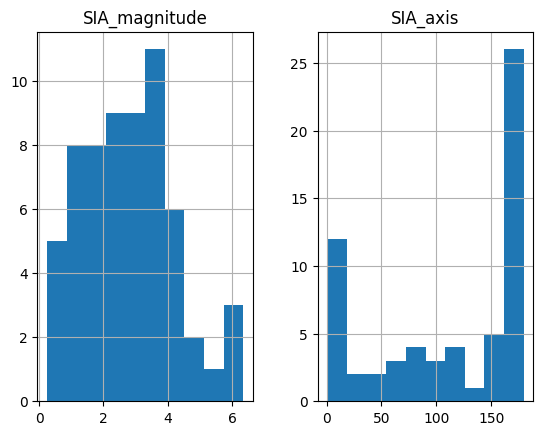

In [16]:
mixed_df1[['SIA_magnitude','SIA_axis']].hist()

<Axes: >

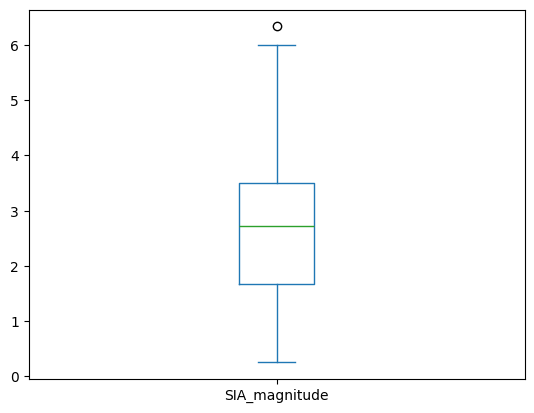

In [17]:
mixed_df1['SIA_magnitude'].plot.box()

<Axes: >

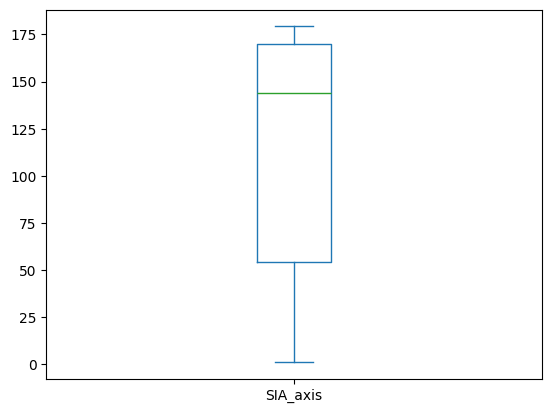

In [18]:
mixed_df1['SIA_axis'].plot.box()

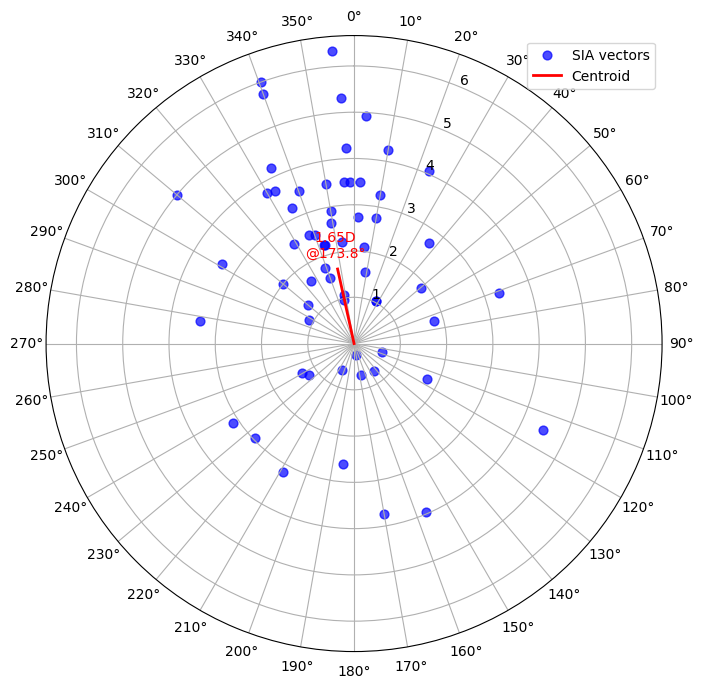

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure required columns exist
required_cols = ['sia_x', 'sia_y', 'SIA_magnitude', 'SIA_axis']
missing_cols = [col for col in required_cols if col not in mixed_df1.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# --- Compute centroid ---
centroid_x = mixed_df1['sia_x'].mean()
centroid_y = mixed_df1['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# --- Convert data points to polar ---
theta = np.deg2rad(mixed_df1['SIA_axis'] * 2)  # double-angle domain
r = mixed_df1['SIA_magnitude']

# --- Plot ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 10))  # 10° spacing

# Plot SIA data points
ax.scatter(theta, r, color='blue', s=40, alpha=0.7, label='SIA vectors')

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_mag], color='red', linewidth=2, label='Centroid')

# Label the centroid
ax.text(centroid_theta, centroid_mag + 0.2,
        f"{centroid_mag:.2f}D\n@{centroid_axis:.1f}°",
        ha='center', va='bottom', fontsize=10, color='red')

# Final formatting
ax.set_title("", va='bottom')
ax.legend(loc='upper right')
ax.grid(True)
plt.show()

In [20]:
C_myopic_df1.columns

Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'preop logMAR', 'day1 logMAR',
       'SPH', 'CYL', 'AXIS', 'preop_cyl', 'preop_axis', 'postop_cyl',
       'Classification'],
      dtype='object')

In [21]:

# Compound myopic astigmatism SIA vector analysis

# Step 1: Pre- and Post-op Cylinder (using the already calculated 'preopcyl')
C_myopic_df1['postop_cyl'] = C_myopic_df1['CYL']

# Step 2: Convert axis to double angle in radians
C_myopic_df1['pre_theta'] = np.deg2rad(C_myopic_df1['AX'] * 2)
C_myopic_df1['post_theta'] = np.deg2rad(C_myopic_df1['AXIS'] * 2)

# Step 3: Convert to Cartesian coordinates
C_myopic_df1['pre_x'] = C_myopic_df1['preop_cyl'] * np.cos(C_myopic_df1['pre_theta'])
C_myopic_df1['pre_y'] = C_myopic_df1['preop_cyl'] * np.sin(C_myopic_df1['pre_theta'])

C_myopic_df1['post_x'] = C_myopic_df1['postop_cyl'] * np.cos(C_myopic_df1['post_theta'])
C_myopic_df1['post_y'] = C_myopic_df1['postop_cyl'] * np.sin(C_myopic_df1['post_theta'])

# Step 4: Compute SIA vector components
C_myopic_df1['sia_x'] = C_myopic_df1['post_x'] - C_myopic_df1['pre_x']
C_myopic_df1['sia_y'] = C_myopic_df1['post_y'] - C_myopic_df1['pre_y']

# Step 5: Compute SIA magnitude and axis
C_myopic_df1['SIA_magnitude'] = np.sqrt(C_myopic_df1['sia_x']**2 + C_myopic_df1['sia_y']**2)
C_myopic_df1['SIA_axis'] = (np.rad2deg(np.arctan2(C_myopic_df1['sia_y'], C_myopic_df1['sia_x'])) / 2) % 180

# Step 6: Round for neat display
C_myopic_df1['SIA_magnitude'] = C_myopic_df1['SIA_magnitude'].round(2)
C_myopic_df1['SIA_axis'] = C_myopic_df1['SIA_axis'].round(1)

# Show the final results
print(C_myopic_df1[['SIA_magnitude', 'SIA_axis']].describe())


       SIA_magnitude    SIA_axis
count      48.000000   48.000000
mean        2.098333   93.658333
std         1.319086   61.033628
min         0.170000    0.500000
25%         1.220000   36.625000
50%         1.745000   97.900000
75%         2.925000  154.125000
max         5.410000  177.500000


/tmp/ipython-input-140790579.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_myopic_df1['postop_cyl'] = C_myopic_df1['CYL']
/tmp/ipython-input-140790579.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_myopic_df1['pre_theta'] = np.deg2rad(C_myopic_df1['AX'] * 2)
/tmp/ipython-input-140790579.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

In [22]:
C_myopic_df1[['SIA_magnitude','SIA_axis']].describe()

,SIA_magnitude,SIA_axis
count,48.000000,48.000000
mean,2.098333,93.658333
std,1.319086,61.033628
min,0.170000,0.500000
25%,1.220000,36.625000
50%,1.745000,97.900000
75%,2.925000,154.125000
max,5.410000,177.500000


array([[<Axes: title={'center': 'SIA_magnitude'}>,
        <Axes: title={'center': 'SIA_axis'}>]], dtype=object)

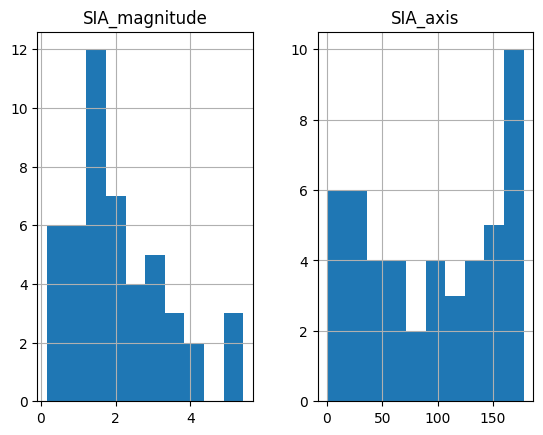

In [23]:
C_myopic_df1[['SIA_magnitude','SIA_axis']].hist()

<Axes: >

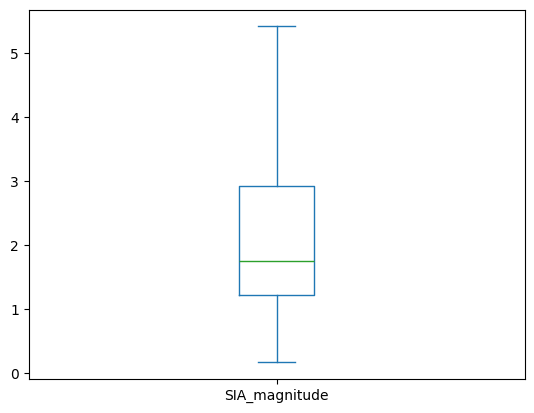

In [24]:
C_myopic_df1[['SIA_magnitude']].plot.box()

<Axes: >

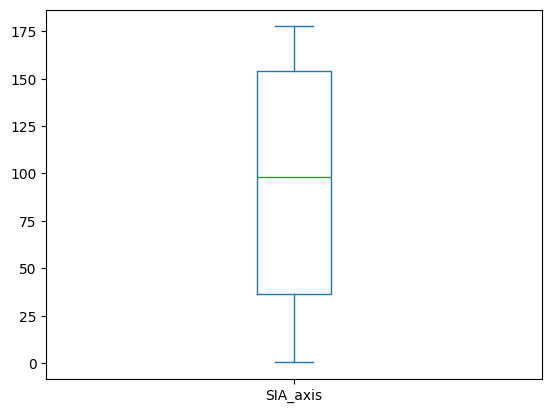

In [25]:
C_myopic_df1[['SIA_axis']].plot.box()

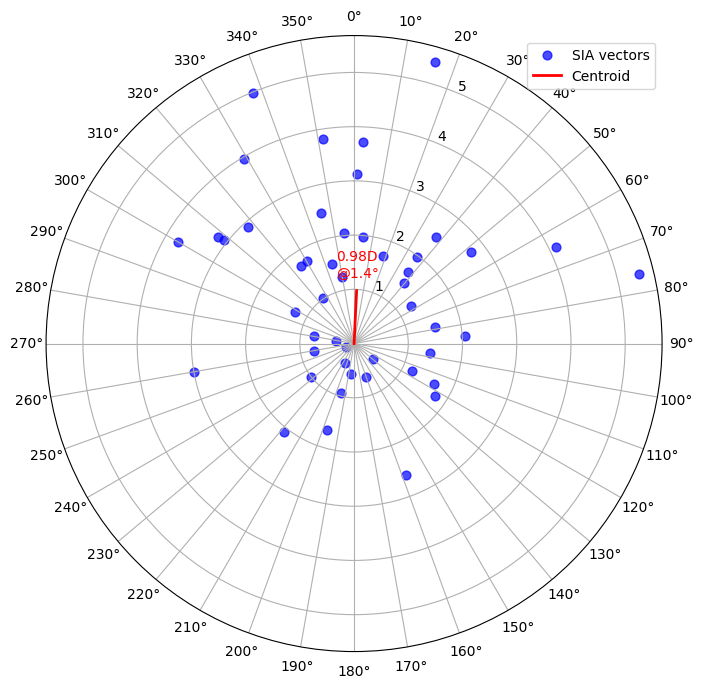

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure required columns exist
required_cols = ['sia_x', 'sia_y', 'SIA_magnitude', 'SIA_axis']
missing_cols = [col for col in required_cols if col not in C_myopic_df1.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# --- Compute centroid ---
centroid_x = C_myopic_df1['sia_x'].mean()
centroid_y = C_myopic_df1['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# --- Convert data points to polar ---
theta = np.deg2rad(C_myopic_df1['SIA_axis'] * 2)  # double-angle domain
r = C_myopic_df1['SIA_magnitude']

# --- Plot ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 10))  # 10° spacing

# Plot SIA data points
ax.scatter(theta, r, color='blue', s=40, alpha=0.7, label='SIA vectors')

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_mag], color='red', linewidth=2, label='Centroid')

# Label the centroid
ax.text(centroid_theta, centroid_mag + 0.2,
        f"{centroid_mag:.2f}D\n@{centroid_axis:.1f}°",
        ha='center', va='bottom', fontsize=10, color='red')

# Final formatting
ax.set_title("", va='bottom')
ax.legend(loc='upper right')
ax.grid(True)
plt.show()

In [27]:
C_hyperopic_df1.shape, C_hyperopic_df1.columns

((14, 14),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'preop logMAR', 'day1 logMAR',
        'SPH', 'CYL', 'AXIS', 'preop_cyl', 'preop_axis', 'postop_cyl',
        'Classification'],
       dtype='object'))

In [28]:

# Compound hyperopic astigmatism SIA vector analysis

# Step 1: Pre- and Post-op Cylinder (using the already calculated 'preopcyl')
C_hyperopic_df1['postop_cyl'] = C_hyperopic_df1['CYL']

# Step 2: Convert axis to double angle in radians
C_hyperopic_df1['pre_theta'] = np.deg2rad(C_hyperopic_df1['AX'] * 2)
C_hyperopic_df1['post_theta'] = np.deg2rad(C_hyperopic_df1['AXIS'] * 2)

# Step 3: Convert to Cartesian coordinates
C_hyperopic_df1['pre_x'] = C_hyperopic_df1['preop_cyl'] * np.cos(C_hyperopic_df1['pre_theta'])
C_hyperopic_df1['pre_y'] = C_hyperopic_df1['preop_cyl'] * np.sin(C_hyperopic_df1['pre_theta'])

C_hyperopic_df1['post_x'] = C_hyperopic_df1['postop_cyl'] * np.cos(C_hyperopic_df1['post_theta'])
C_hyperopic_df1['post_y'] = C_hyperopic_df1['postop_cyl'] * np.sin(C_hyperopic_df1['post_theta'])

# Step 4: Compute SIA vector components
C_hyperopic_df1['sia_x'] = C_hyperopic_df1['post_x'] - C_hyperopic_df1['pre_x']
C_hyperopic_df1['sia_y'] = C_hyperopic_df1['post_y'] - C_hyperopic_df1['pre_y']

# Step 5: Compute SIA magnitude and axis
C_hyperopic_df1['SIA_magnitude'] = np.sqrt(C_hyperopic_df1['sia_x']**2 + C_hyperopic_df1['sia_y']**2)
C_hyperopic_df1['SIA_axis'] = (np.rad2deg(np.arctan2(C_hyperopic_df1['sia_y'], C_hyperopic_df1['sia_x'])) / 2) % 180

# Step 6: Round for neat display
C_hyperopic_df1['SIA_magnitude'] = C_hyperopic_df1['SIA_magnitude'].round(2)
C_hyperopic_df1['SIA_axis'] = C_hyperopic_df1['SIA_axis'].round(1)

# Show the final results
print(C_hyperopic_df1[['SIA_magnitude', 'SIA_axis']].describe())


       SIA_magnitude    SIA_axis
count      14.000000   14.000000
mean        1.719286  107.128571
std         1.142059   45.966784
min         0.520000   20.100000
25%         0.712500   80.925000
50%         1.150000  112.100000
75%         2.877500  139.550000
max         3.450000  178.900000


/tmp/ipython-input-1270377486.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_hyperopic_df1['postop_cyl'] = C_hyperopic_df1['CYL']
/tmp/ipython-input-1270377486.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_hyperopic_df1['pre_theta'] = np.deg2rad(C_hyperopic_df1['AX'] * 2)
/tmp/ipython-input-1270377486.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

In [29]:
C_hyperopic_df1[['SIA_magnitude', 'SIA_axis']].describe()

,SIA_magnitude,SIA_axis
count,14.000000,14.000000
mean,1.719286,107.128571
std,1.142059,45.966784
min,0.520000,20.100000
25%,0.712500,80.925000
50%,1.150000,112.100000
75%,2.877500,139.550000
max,3.450000,178.900000


array([[<Axes: title={'center': 'SIA_magnitude'}>,
        <Axes: title={'center': 'SIA_axis'}>]], dtype=object)

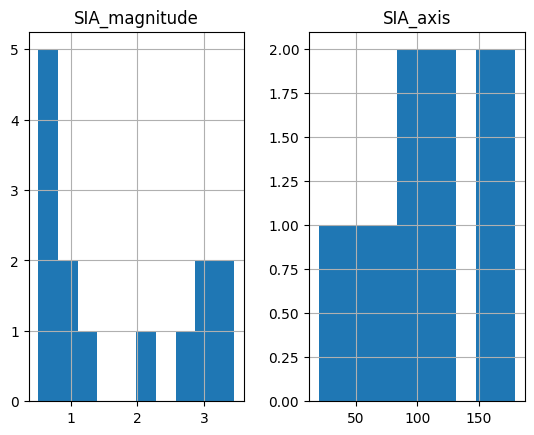

In [30]:
C_hyperopic_df1[['SIA_magnitude', 'SIA_axis']].hist()

<Axes: >

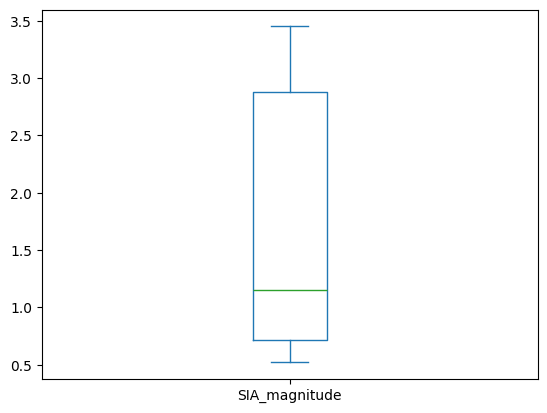

In [31]:
C_hyperopic_df1[['SIA_magnitude']].plot.box()

<Axes: >

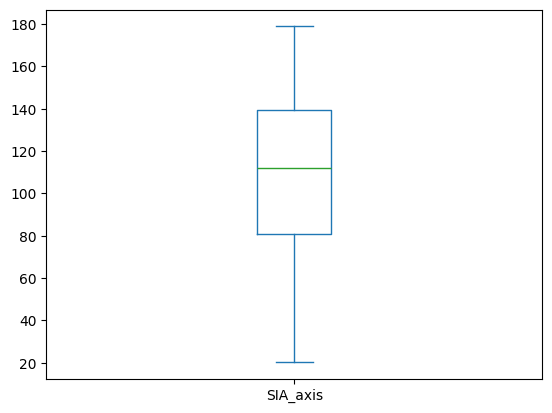

In [32]:
C_hyperopic_df1[['SIA_axis']].plot.box()

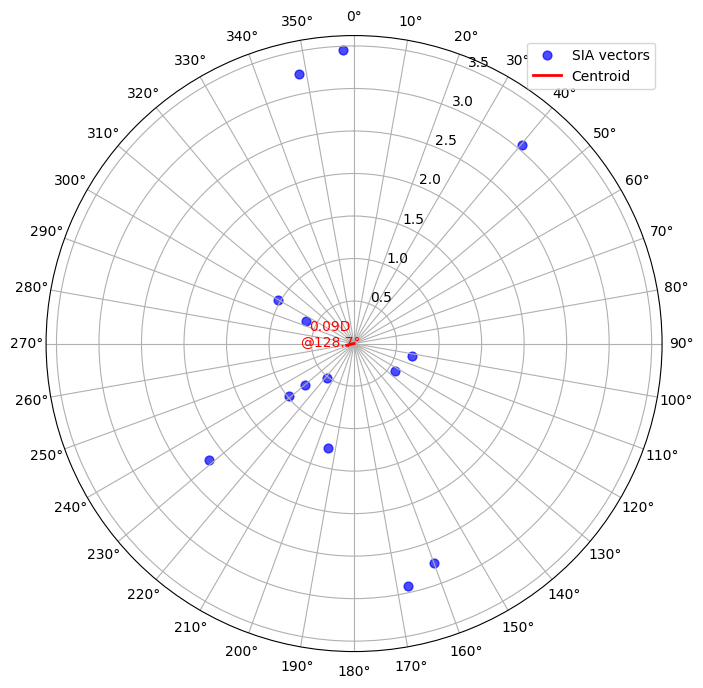

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure required columns exist
required_cols = ['sia_x', 'sia_y', 'SIA_magnitude', 'SIA_axis']
missing_cols = [col for col in required_cols if col not in C_hyperopic_df1.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# --- Compute centroid ---
centroid_x = C_hyperopic_df1['sia_x'].mean()
centroid_y = C_hyperopic_df1['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# --- Convert data points to polar ---
theta = np.deg2rad(C_hyperopic_df1['SIA_axis'] * 2)  # double-angle domain
r = C_hyperopic_df1['SIA_magnitude']

# --- Plot ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 10))  # 10° spacing

# Plot SIA data points
ax.scatter(theta, r, color='blue', s=40, alpha=0.7, label='SIA vectors')

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_mag], color='red', linewidth=2, label='Centroid')

# Label the centroid
ax.text(centroid_theta, centroid_mag + 0.2,
        f"{centroid_mag:.2f}D\n@{centroid_axis:.1f}°",
        ha='center', va='bottom', fontsize=10, color='red')

# Final formatting
ax.set_title("", va='bottom')
ax.legend(loc='upper right')
ax.grid(True)
plt.show()

In [34]:
S_myopic_df1.shape, S_myopic_df1.columns

((6, 14),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'preop logMAR', 'day1 logMAR',
        'SPH', 'CYL', 'AXIS', 'preop_cyl', 'preop_axis', 'postop_cyl',
        'Classification'],
       dtype='object'))

In [35]:
# Compound myopic astigmatism SIA vector analysis

# Step 1: Pre- and Post-op Cylinder (using the already calculated 'preopcyl')
S_myopic_df1['postop_cyl'] = S_myopic_df1['CYL']

# Step 2: Convert axis to double angle in radians
S_myopic_df1['pre_theta'] = np.deg2rad(S_myopic_df1['AX'] * 2)
S_myopic_df1['post_theta'] = np.deg2rad(S_myopic_df1['AXIS'] * 2)

# Step 3: Convert to Cartesian coordinates
S_myopic_df1['pre_x'] = S_myopic_df1['preop_cyl'] * np.cos(S_myopic_df1['pre_theta'])
S_myopic_df1['pre_y'] = S_myopic_df1['preop_cyl'] * np.sin(S_myopic_df1['pre_theta'])

S_myopic_df1['post_x'] = S_myopic_df1['postop_cyl'] * np.cos(S_myopic_df1['post_theta'])
S_myopic_df1['post_y'] = S_myopic_df1['postop_cyl'] * np.sin(S_myopic_df1['post_theta'])

# Step 4: Compute SIA vector components
S_myopic_df1['sia_x'] = S_myopic_df1['post_x'] - S_myopic_df1['pre_x']
S_myopic_df1['sia_y'] = S_myopic_df1['post_y'] - S_myopic_df1['pre_y']

# Step 5: Compute SIA magnitude and axis
S_myopic_df1['SIA_magnitude'] = np.sqrt(S_myopic_df1['sia_x']**2 + S_myopic_df1['sia_y']**2)
S_myopic_df1['SIA_axis'] = (np.rad2deg(np.arctan2(S_myopic_df1['sia_y'], S_myopic_df1['sia_x'])) / 2) % 180

# Step 6: Round for neat display
S_myopic_df1['SIA_magnitude'] = S_myopic_df1['SIA_magnitude'].round(2)
S_myopic_df1['SIA_axis'] = S_myopic_df1['SIA_axis'].round(1)

# Show the final results
print(S_myopic_df1[['SIA_magnitude', 'SIA_axis']].describe())


       SIA_magnitude    SIA_axis
count       6.000000    6.000000
mean        1.380000   80.366667
std         1.028863   51.770481
min         0.510000   31.200000
25%         0.595000   45.250000
50%         0.975000   65.100000
75%         2.015000  100.400000
max         2.990000  170.000000


/tmp/ipython-input-3871175642.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_myopic_df1['postop_cyl'] = S_myopic_df1['CYL']
/tmp/ipython-input-3871175642.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_myopic_df1['pre_theta'] = np.deg2rad(S_myopic_df1['AX'] * 2)
/tmp/ipython-input-3871175642.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

In [36]:
S_myopic_df1[['SIA_magnitude', 'SIA_axis']].describe()

,SIA_magnitude,SIA_axis
count,6.000000,6.000000
mean,1.380000,80.366667
std,1.028863,51.770481
min,0.510000,31.200000
25%,0.595000,45.250000
50%,0.975000,65.100000
75%,2.015000,100.400000
max,2.990000,170.000000


array([[<Axes: title={'center': 'SIA_magnitude'}>,
        <Axes: title={'center': 'SIA_axis'}>]], dtype=object)

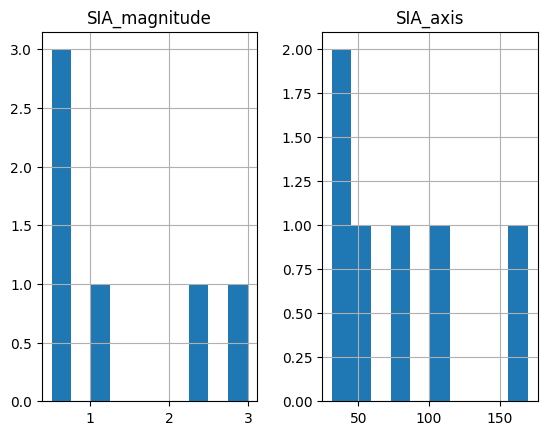

In [37]:
S_myopic_df1[['SIA_magnitude', 'SIA_axis']].hist()

<Axes: >

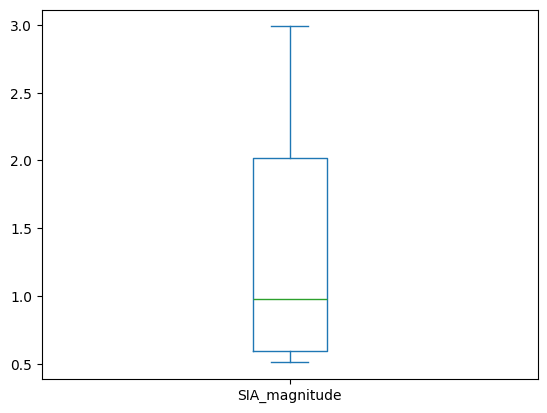

In [38]:
S_myopic_df1[['SIA_magnitude']].plot.box()

<Axes: >

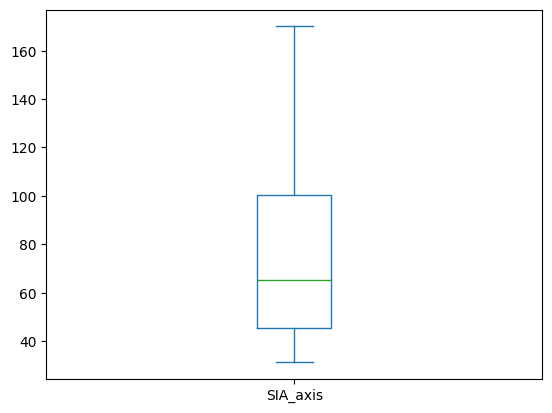

In [39]:
S_myopic_df1[['SIA_axis']].plot.box()

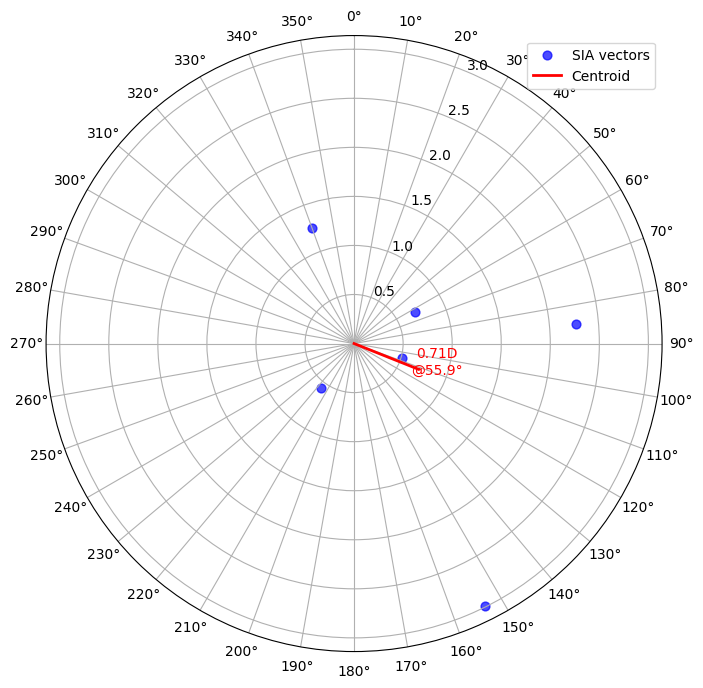

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure required columns exist
required_cols = ['sia_x', 'sia_y', 'SIA_magnitude', 'SIA_axis']
missing_cols = [col for col in required_cols if col not in S_myopic_df1.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# --- Compute centroid ---
centroid_x = S_myopic_df1['sia_x'].mean()
centroid_y = S_myopic_df1['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# --- Convert data points to polar ---
theta = np.deg2rad(S_myopic_df1['SIA_axis'] * 2)  # double-angle domain
r = S_myopic_df1['SIA_magnitude']

# --- Plot ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 10))  # 10° spacing

# Plot SIA data points
ax.scatter(theta, r, color='blue', s=40, alpha=0.7, label='SIA vectors')

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_mag], color='red', linewidth=2, label='Centroid')

# Label the centroid
ax.text(centroid_theta, centroid_mag + 0.2,
        f"{centroid_mag:.2f}D\n@{centroid_axis:.1f}°",
        ha='center', va='bottom', fontsize=10, color='red')

# Final formatting
ax.set_title("", va='bottom')
ax.legend(loc='upper right')
ax.grid(True)
plt.show()

In [41]:
S_hyperopic_df1.shape, S_hyperopic_df1.columns

((1, 14),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'preop logMAR', 'day1 logMAR',
        'SPH', 'CYL', 'AXIS', 'preop_cyl', 'preop_axis', 'postop_cyl',
        'Classification'],
       dtype='object'))

In [42]:
# Simple hyperopic astigmatism SIA vector analysis

# Step 1: Pre- and Post-op Cylinder (using the already calculated 'preopcyl')
S_hyperopic_df1['postop_cyl'] = S_hyperopic_df1['CYL']

# Step 2: Convert axis to double angle in radians
S_hyperopic_df1['pre_theta'] = np.deg2rad(S_hyperopic_df1['AX'] * 2)
S_hyperopic_df1['post_theta'] = np.deg2rad(S_hyperopic_df1['AXIS'] * 2)

# Step 3: Convert to Cartesian coordinates
S_hyperopic_df1['pre_x'] = S_hyperopic_df1['preop_cyl'] * np.cos(S_hyperopic_df1['pre_theta'])
S_hyperopic_df1['pre_y'] = S_hyperopic_df1['preop_cyl'] * np.sin(S_hyperopic_df1['pre_theta'])

S_hyperopic_df1['post_x'] = S_hyperopic_df1['postop_cyl'] * np.cos(S_hyperopic_df1['post_theta'])
S_hyperopic_df1['post_y'] = S_hyperopic_df1['postop_cyl'] * np.sin(S_hyperopic_df1['post_theta'])

# Step 4: Compute SIA vector components
S_hyperopic_df1['sia_x'] = S_hyperopic_df1['post_x'] - S_hyperopic_df1['pre_x']
S_hyperopic_df1['sia_y'] = S_hyperopic_df1['post_y'] - S_hyperopic_df1['pre_y']

# Step 5: Compute SIA magnitude and axis
S_hyperopic_df1['SIA_magnitude'] = np.sqrt(S_hyperopic_df1['sia_x']**2 + S_hyperopic_df1['sia_y']**2)
S_hyperopic_df1['SIA_axis'] = (np.rad2deg(np.arctan2(S_hyperopic_df1['sia_y'], S_hyperopic_df1['sia_x'])) / 2) % 180

# Step 6: Round for neat display
S_hyperopic_df1['SIA_magnitude'] = S_hyperopic_df1['SIA_magnitude'].round(2)
S_hyperopic_df1['SIA_axis'] = S_hyperopic_df1['SIA_axis'].round(1)

# Show the final results
print(S_hyperopic_df1[['SIA_magnitude', 'SIA_axis']].describe())


       SIA_magnitude  SIA_axis
count           1.00       1.0
mean            1.22      92.9
std              NaN       NaN
min             1.22      92.9
25%             1.22      92.9
50%             1.22      92.9
75%             1.22      92.9
max             1.22      92.9


/tmp/ipython-input-3485153101.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_hyperopic_df1['postop_cyl'] = S_hyperopic_df1['CYL']
/tmp/ipython-input-3485153101.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_hyperopic_df1['pre_theta'] = np.deg2rad(S_hyperopic_df1['AX'] * 2)
/tmp/ipython-input-3485153101.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

In [43]:
S_hyperopic_df1[['SIA_magnitude', 'SIA_axis']].describe()

,SIA_magnitude,SIA_axis
count,1.00,1.0
mean,1.22,92.9
std,NaN,NaN
min,1.22,92.9
25%,1.22,92.9
50%,1.22,92.9
75%,1.22,92.9
max,1.22,92.9


array([[<Axes: title={'center': 'SIA_magnitude'}>,
        <Axes: title={'center': 'SIA_axis'}>]], dtype=object)

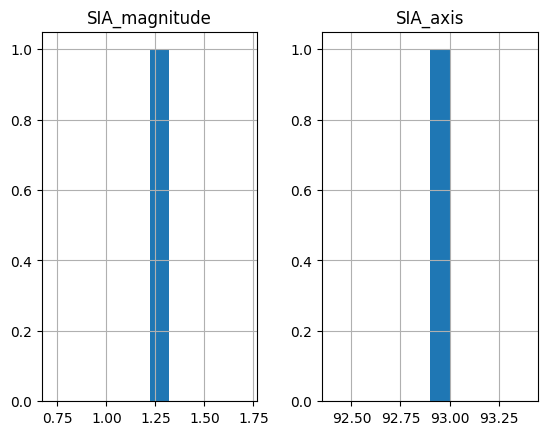

In [44]:
S_hyperopic_df1[['SIA_magnitude', 'SIA_axis']].hist()

<Axes: >

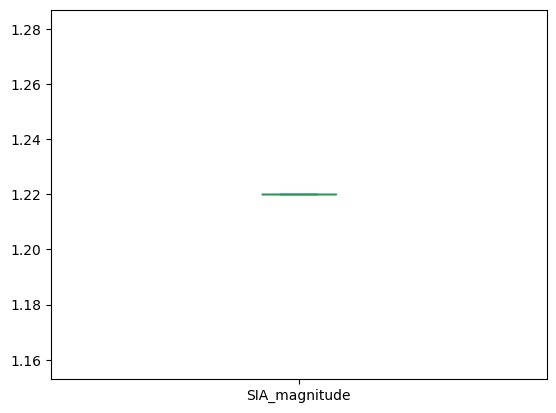

In [45]:
S_hyperopic_df1[['SIA_magnitude']].plot.box()

<Axes: >

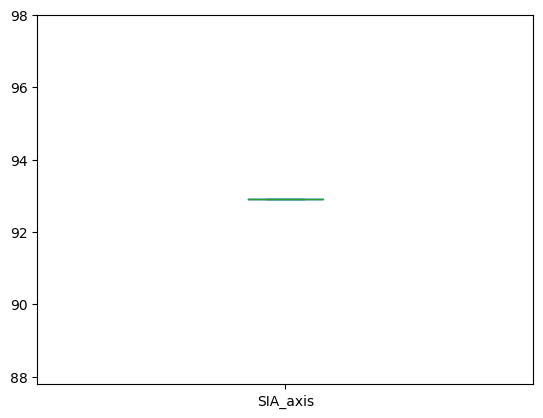

In [46]:
S_hyperopic_df1[['SIA_axis']].plot.box()

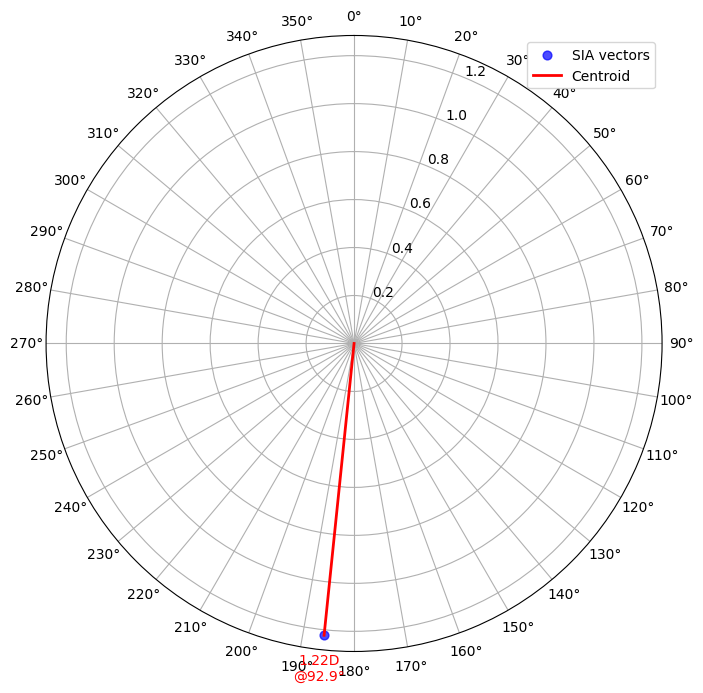

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure required columns exist
required_cols = ['sia_x', 'sia_y', 'SIA_magnitude', 'SIA_axis']
missing_cols = [col for col in required_cols if col not in S_hyperopic_df1.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# --- Compute centroid ---
centroid_x = S_hyperopic_df1['sia_x'].mean()
centroid_y = S_hyperopic_df1['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# --- Convert data points to polar ---
theta = np.deg2rad(S_hyperopic_df1['SIA_axis'] * 2)  # double-angle domain
r = S_hyperopic_df1['SIA_magnitude']

# --- Plot ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 10))  # 10° spacing

# Plot SIA data points
ax.scatter(theta, r, color='blue', s=40, alpha=0.7, label='SIA vectors')

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_mag], color='red', linewidth=2, label='Centroid')

# Label the centroid
ax.text(centroid_theta, centroid_mag + 0.2,
        f"{centroid_mag:.2f}D\n@{centroid_axis:.1f}°",
        ha='center', va='bottom', fontsize=10, color='red')

# Final formatting
ax.set_title("", va='bottom')
ax.legend(loc='upper right')
ax.grid(True)
plt.show()

In [48]:
wk6AR.shape, wk6AR.columns

((171, 12),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'POD 6 WEEK V/A ', 'numerator',
        'denominator', 'wk6 logMAR', 'SPH ', 'CYL.1', 'AXIS.1'],
       dtype='object'))

In [49]:
wk6ARF2 = wk6AR[['AGE','SEX_numeric','KH','KV','AX','wk6 logMAR', 'SPH ', 'CYL.1', 'AXIS.1']]
wk6ARF2.shape, wk6ARF2.columns

((171, 9),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'wk6 logMAR', 'SPH ', 'CYL.1',
        'AXIS.1'],
       dtype='object'))

In [50]:
# Create a new column 'Classification' in day1ARclean
wk6ARF2['Classification'] = wk6ARF2.apply(
    lambda row: 'Compound myopic astigmatism' if row['SPH '] < 0 and row['CYL.1'] < 0 else
                'Compound hyperopic astigmatism' if row['SPH '] > 0 and row['CYL.1'] > 0 else
    'Simple myopic astigmatism' if row['SPH '] == 0 and row['CYL.1'] < 0 else
    'Simple hyperopic astigmatism' if row['SPH '] == 0 and row['CYL.1'] > 0 else
                'Mixed astigmatism',
    axis=1
)

# View result
print(wk6ARF2[['SPH ', 'CYL.1', 'AXIS.1','Classification']])

     SPH   CYL.1  AXIS.1                  Classification
0    0.25  -1.25     100               Mixed astigmatism
1    0.75  -2.00      90               Mixed astigmatism
2   -1.50  -1.00     140     Compound myopic astigmatism
3   -0.50  -0.75     140     Compound myopic astigmatism
4    0.25   2.25      85  Compound hyperopic astigmatism
..    ...    ...     ...                             ...
166 -2.00  -2.50     110     Compound myopic astigmatism
167 -2.00  -1.25      90     Compound myopic astigmatism
168 -2.50  -4.25      10     Compound myopic astigmatism
169 -1.00   3.25     150               Mixed astigmatism
170 -3.50  -2.75      75     Compound myopic astigmatism

[171 rows x 4 columns]


/tmp/ipython-input-283886431.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wk6ARF2['Classification'] = wk6ARF2.apply(


In [51]:
# Frequency of each refractive error type
classification_counts = wk6ARF2['Classification'].value_counts()
print(classification_counts)


Classification
Mixed astigmatism                 78
Compound myopic astigmatism       64
Compound hyperopic astigmatism    17
Simple myopic astigmatism         11
Simple hyperopic astigmatism       1
Name: count, dtype: int64


In [52]:
# Separate Astigmatisms
mixed_df2 = wk6ARF2[wk6ARF2['Classification'] == 'Mixed astigmatism']
C_myopic_df2 = wk6ARF2[wk6ARF2['Classification']=='Compound myopic astigmatism']
C_hyperopic_df2 = wk6ARF2[wk6ARF2['Classification']=='Compound hyperopic astigmatism']
S_myopic_df2 = wk6ARF2[wk6ARF2['Classification'] == 'Simple myopic astigmatism']
S_hyperopic_df2 = wk6ARF2[wk6ARF2['Classification'] == 'Simple hyperopic astigmatism']


In [53]:
# Mixed astigmatism SIA vector analysis (for mixed_df2)

# Step 1: Pre- and Post-op Cylinder
# If not already calculated, compute preop_cyl
mixed_df2['preop_cyl'] = mixed_df2['KV'] - mixed_df2['KH']
mixed_df2['postop_cyl'] = mixed_df2['CYL.1']   # or use another post-op cyl column if available

# Step 2: Convert axis to double angle in radians
mixed_df2['pre_theta'] = np.deg2rad(mixed_df2['AX'] * 2)
mixed_df2['post_theta'] = np.deg2rad(mixed_df2['AXIS.1'] * 2)

# Step 3: Convert to Cartesian coordinates
mixed_df2['pre_x'] = mixed_df2['preop_cyl'] * np.cos(mixed_df2['pre_theta'])
mixed_df2['pre_y'] = mixed_df2['preop_cyl'] * np.sin(mixed_df2['pre_theta'])

mixed_df2['post_x'] = mixed_df2['postop_cyl'] * np.cos(mixed_df2['post_theta'])
mixed_df2['post_y'] = mixed_df2['postop_cyl'] * np.sin(mixed_df2['post_theta'])

# Step 4: Compute SIA vector components
mixed_df2['sia_x'] = mixed_df2['post_x'] - mixed_df2['pre_x']
mixed_df2['sia_y'] = mixed_df2['post_y'] - mixed_df2['pre_y']

# Step 5: Compute SIA magnitude and axis
mixed_df2['SIA_magnitude'] = np.sqrt(mixed_df2['sia_x']**2 + mixed_df2['sia_y']**2)
mixed_df2['SIA_axis'] = (np.rad2deg(np.arctan2(mixed_df2['sia_y'], mixed_df2['sia_x'])) / 2) % 180

# Step 6: Round for neat display
mixed_df2['SIA_magnitude'] = mixed_df2['SIA_magnitude'].round(2)
mixed_df2['SIA_axis'] = mixed_df2['SIA_axis'].round(1)

# Show the final results
print(mixed_df2[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
0             1.22      27.7
1             3.20     176.2
5             2.99     168.3
8             3.47       3.6
9             2.71     155.9
..             ...       ...
156           4.50      70.0
160           3.00     170.0
163           1.48      84.8
164           0.54      21.4
169           2.88     146.8

[78 rows x 2 columns]


/tmp/ipython-input-1108559940.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df2['preop_cyl'] = mixed_df2['KV'] - mixed_df2['KH']
/tmp/ipython-input-1108559940.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df2['postop_cyl'] = mixed_df2['CYL.1']   # or use another post-op cyl column if available
/tmp/ipython-input-1108559940.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [54]:
# Compound myopic astigmatism SIA vector analysis (for C_myopic_df2)

# Step 1: Pre- and Post-op Cylinder
# If not already calculated, compute preop_cyl
C_myopic_df2['preop_cyl'] = C_myopic_df2['KV'] - C_myopic_df2['KH']
C_myopic_df2['postop_cyl'] = C_myopic_df2['CYL.1']   # or use another post-op cyl column if available

# Step 2: Convert axis to double angle in radians
C_myopic_df2['pre_theta'] = np.deg2rad(C_myopic_df2['AX'] * 2)
C_myopic_df2['post_theta'] = np.deg2rad(C_myopic_df2['AXIS.1'] * 2)

# Step 3: Convert to Cartesian coordinates
C_myopic_df2['pre_x'] = C_myopic_df2['preop_cyl'] * np.cos(C_myopic_df2['pre_theta'])
C_myopic_df2['pre_y'] = C_myopic_df2['preop_cyl'] * np.sin(C_myopic_df2['pre_theta'])

C_myopic_df2['post_x'] = C_myopic_df2['postop_cyl'] * np.cos(C_myopic_df2['post_theta'])
C_myopic_df2['post_y'] = C_myopic_df2['postop_cyl'] * np.sin(C_myopic_df2['post_theta'])

# Step 4: Compute SIA vector components
C_myopic_df2['sia_x'] = C_myopic_df2['post_x'] - C_myopic_df2['pre_x']
C_myopic_df2['sia_y'] = C_myopic_df2['post_y'] - C_myopic_df2['pre_y']

# Step 5: Compute SIA magnitude and axis
C_myopic_df2['SIA_magnitude'] = np.sqrt(C_myopic_df2['sia_x']**2 + C_myopic_df2['sia_y']**2)
C_myopic_df2['SIA_axis'] = (np.rad2deg(np.arctan2(C_myopic_df2['sia_y'], C_myopic_df2['sia_x'])) / 2) % 180

# Step 6: Round for neat display
C_myopic_df2['SIA_magnitude'] = C_myopic_df2['SIA_magnitude'].round(2)
C_myopic_df2['SIA_axis'] = C_myopic_df2['SIA_axis'].round(1)

# Show the final results
print(C_myopic_df2[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
2             0.90      56.9
3             1.18      42.1
7             3.70     174.0
12            2.13       0.3
17            2.04      92.4
..             ...       ...
165           1.04     164.2
166           2.38      34.8
167           2.74     177.3
168           3.69     106.0
170           2.75     165.0

[64 rows x 2 columns]


/tmp/ipython-input-1399781651.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_myopic_df2['preop_cyl'] = C_myopic_df2['KV'] - C_myopic_df2['KH']
/tmp/ipython-input-1399781651.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_myopic_df2['postop_cyl'] = C_myopic_df2['CYL.1']   # or use another post-op cyl column if available
/tmp/ipython-input-1399781651.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

In [55]:
# Compound hyperopic astigmatism SIA vector analysis (for C_hyperopic_df2)

# Step 1: Pre- and Post-op Cylinder
# If not already calculated, compute preop_cyl
C_hyperopic_df2['preop_cyl'] = C_hyperopic_df2['KV'] - C_hyperopic_df2['KH']
C_hyperopic_df2['postop_cyl'] = C_hyperopic_df2['CYL.1']   # or another post-op cyl column if available

# Step 2: Convert axis to double angle in radians
C_hyperopic_df2['pre_theta'] = np.deg2rad(C_hyperopic_df2['AX'] * 2)
C_hyperopic_df2['post_theta'] = np.deg2rad(C_hyperopic_df2['AXIS.1'] * 2)

# Step 3: Convert to Cartesian coordinates
C_hyperopic_df2['pre_x'] = C_hyperopic_df2['preop_cyl'] * np.cos(C_hyperopic_df2['pre_theta'])
C_hyperopic_df2['pre_y'] = C_hyperopic_df2['preop_cyl'] * np.sin(C_hyperopic_df2['pre_theta'])

C_hyperopic_df2['post_x'] = C_hyperopic_df2['postop_cyl'] * np.cos(C_hyperopic_df2['post_theta'])
C_hyperopic_df2['post_y'] = C_hyperopic_df2['postop_cyl'] * np.sin(C_hyperopic_df2['post_theta'])

# Step 4: Compute SIA vector components
C_hyperopic_df2['sia_x'] = C_hyperopic_df2['post_x'] - C_hyperopic_df2['pre_x']
C_hyperopic_df2['sia_y'] = C_hyperopic_df2['post_y'] - C_hyperopic_df2['pre_y']

# Step 5: Compute SIA magnitude and axis
C_hyperopic_df2['SIA_magnitude'] = np.sqrt(C_hyperopic_df2['sia_x']**2 + C_hyperopic_df2['sia_y']**2)
C_hyperopic_df2['SIA_axis'] = (np.rad2deg(np.arctan2(C_hyperopic_df2['sia_y'], C_hyperopic_df2['sia_x'])) / 2) % 180

# Step 6: Round for neat display
C_hyperopic_df2['SIA_magnitude'] = C_hyperopic_df2['SIA_magnitude'].round(2)
C_hyperopic_df2['SIA_axis'] = C_hyperopic_df2['SIA_axis'].round(1)

# Show the final results
print(C_hyperopic_df2[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
4             0.82      94.3
13            0.85     162.5
19            0.93     108.7
67            2.99      78.8
75            0.63     120.9
88            1.15     165.4
93            0.94     117.2
102           0.98      95.7
108           2.46     162.5
110           0.76      93.3
111           0.90     143.1
123           0.77      61.8
134           2.27      87.2
137           1.41     130.0
145           2.29     155.4
148           4.50      90.0
161           1.65     139.4


/tmp/ipython-input-4218620744.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_hyperopic_df2['preop_cyl'] = C_hyperopic_df2['KV'] - C_hyperopic_df2['KH']
/tmp/ipython-input-4218620744.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_hyperopic_df2['postop_cyl'] = C_hyperopic_df2['CYL.1']   # or another post-op cyl column if available
/tmp/ipython-input-4218620744.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [56]:
# Simple myopic astigmatism SIA vector analysis (for S_myopic_df2)

# Step 1: Pre- and Post-op Cylinder
# If not already calculated, compute preop_cyl
S_myopic_df2['preop_cyl'] = S_myopic_df2['KV'] - S_myopic_df2['KH']
S_myopic_df2['postop_cyl'] = S_myopic_df2['CYL.1']   # or another post-op cyl column if available

# Step 2: Convert axis to double angle in radians
S_myopic_df2['pre_theta'] = np.deg2rad(S_myopic_df2['AX'] * 2)
S_myopic_df2['post_theta'] = np.deg2rad(S_myopic_df2['AXIS.1'] * 2)

# Step 3: Convert to Cartesian coordinates
S_myopic_df2['pre_x'] = S_myopic_df2['preop_cyl'] * np.cos(S_myopic_df2['pre_theta'])
S_myopic_df2['pre_y'] = S_myopic_df2['preop_cyl'] * np.sin(S_myopic_df2['pre_theta'])

S_myopic_df2['post_x'] = S_myopic_df2['postop_cyl'] * np.cos(S_myopic_df2['post_theta'])
S_myopic_df2['post_y'] = S_myopic_df2['postop_cyl'] * np.sin(S_myopic_df2['post_theta'])

# Step 4: Compute SIA vector components
S_myopic_df2['sia_x'] = S_myopic_df2['post_x'] - S_myopic_df2['pre_x']
S_myopic_df2['sia_y'] = S_myopic_df2['post_y'] - S_myopic_df2['pre_y']

# Step 5: Compute SIA magnitude and axis
S_myopic_df2['SIA_magnitude'] = np.sqrt(S_myopic_df2['sia_x']**2 + S_myopic_df2['sia_y']**2)
S_myopic_df2['SIA_axis'] = (np.rad2deg(np.arctan2(S_myopic_df2['sia_y'], S_myopic_df2['sia_x'])) / 2) % 180

# Step 6: Round for neat display
S_myopic_df2['SIA_magnitude'] = S_myopic_df2['SIA_magnitude'].round(2)
S_myopic_df2['SIA_axis'] = S_myopic_df2['SIA_axis'].round(1)

# Show the final results
print(S_myopic_df2[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
6             3.28     166.2
11            3.25     120.0
50            0.26     102.5
56            2.24      19.6
83            1.75       5.0
84            1.25      78.4
96            0.42     127.5
103           2.45     132.9
127           0.75     180.0
129           3.15      79.3
131           1.00      20.0


/tmp/ipython-input-3344197979.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_myopic_df2['preop_cyl'] = S_myopic_df2['KV'] - S_myopic_df2['KH']
/tmp/ipython-input-3344197979.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_myopic_df2['postop_cyl'] = S_myopic_df2['CYL.1']   # or another post-op cyl column if available
/tmp/ipython-input-3344197979.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

In [57]:
# Simple hyperopic astigmatism SIA vector analysis (for S_hyperopic_df2)

# Step 1: Pre- and Post-op Cylinder
# If not already calculated, compute preop_cyl
S_hyperopic_df2['preop_cyl'] = S_hyperopic_df2['KV'] - S_hyperopic_df2['KH']
S_hyperopic_df2['postop_cyl'] = S_hyperopic_df2['CYL.1']   # or another post-op cyl column if available

# Step 2: Convert axis to double angle in radians
S_hyperopic_df2['pre_theta'] = np.deg2rad(S_hyperopic_df2['AX'] * 2)
S_hyperopic_df2['post_theta'] = np.deg2rad(S_hyperopic_df2['AXIS.1'] * 2)

# Step 3: Convert to Cartesian coordinates
S_hyperopic_df2['pre_x'] = S_hyperopic_df2['preop_cyl'] * np.cos(S_hyperopic_df2['pre_theta'])
S_hyperopic_df2['pre_y'] = S_hyperopic_df2['preop_cyl'] * np.sin(S_hyperopic_df2['pre_theta'])

S_hyperopic_df2['post_x'] = S_hyperopic_df2['postop_cyl'] * np.cos(S_hyperopic_df2['post_theta'])
S_hyperopic_df2['post_y'] = S_hyperopic_df2['postop_cyl'] * np.sin(S_hyperopic_df2['post_theta'])

# Step 4: Compute SIA vector components
S_hyperopic_df2['sia_x'] = S_hyperopic_df2['post_x'] - S_hyperopic_df2['pre_x']
S_hyperopic_df2['sia_y'] = S_hyperopic_df2['post_y'] - S_hyperopic_df2['pre_y']

# Step 5: Compute SIA magnitude and axis
S_hyperopic_df2['SIA_magnitude'] = np.sqrt(S_hyperopic_df2['sia_x']**2 + S_hyperopic_df2['sia_y']**2)
S_hyperopic_df2['SIA_axis'] = (np.rad2deg(np.arctan2(S_hyperopic_df2['sia_y'], S_hyperopic_df2['sia_x'])) / 2) % 180

# Step 6: Round for neat display
S_hyperopic_df2['SIA_magnitude'] = S_hyperopic_df2['SIA_magnitude'].round(2)
S_hyperopic_df2['SIA_axis'] = S_hyperopic_df2['SIA_axis'].round(1)

# Show the final results
print(S_hyperopic_df2[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
128           0.93      85.9


/tmp/ipython-input-3974069416.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_hyperopic_df2['preop_cyl'] = S_hyperopic_df2['KV'] - S_hyperopic_df2['KH']
/tmp/ipython-input-3974069416.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_hyperopic_df2['postop_cyl'] = S_hyperopic_df2['CYL.1']   # or another post-op cyl column if available
/tmp/ipython-input-3974069416.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [58]:
mth3AR.shape, mth3AR.columns

((174, 12),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'POD 3 MONTH V/A', 'numerator',
        'denominator', 'mth3 logMAR', 'SPH.1', 'CYL ', 'AXIS.2'],
       dtype='object'))

In [59]:
mth3ARF3 = mth3AR[['AGE','SEX_numeric','KH','KV','AX','mth3 logMAR', 'SPH.1', 'CYL ', 'AXIS.2']]
mth3ARF3.shape, mth3ARF3.columns

((174, 9),
 Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'mth3 logMAR', 'SPH.1', 'CYL ',
        'AXIS.2'],
       dtype='object'))

In [60]:
mth3ARF3.dropna(inplace=True)

/tmp/ipython-input-2431098574.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mth3ARF3.dropna(inplace=True)


In [61]:
mth3ARF3.isnull().sum()

,0
AGE,0
SEX_numeric,0
KH,0
KV,0
AX,0
mth3 logMAR,0
SPH.1,0
CYL,0
AXIS.2,0


In [62]:
# Create a new column 'Classification' in day1ARclean
mth3ARF3['Classification'] = mth3ARF3.apply(
    lambda row: 'Compound myopic astigmatism' if row['SPH.1'] < 0 and row['CYL '] < 0 else
                'Compound hyperopic astigmatism' if row['SPH.1'] > 0 and row['CYL '] > 0 else
    'Simple myopic astigmatism' if row['SPH.1'] == 0 and row['CYL '] < 0 else
    'Simple hyperopic astigmatism' if row['SPH.1'] == 0 and row['CYL '] > 0 else
                'Mixed astigmatism',
    axis=1
)

# View result
print(mth3ARF3[['SPH.1', 'CYL ', 'AXIS.2','Classification']])

     SPH.1  CYL   AXIS.2                Classification
0     0.50 -1.00    65.0             Mixed astigmatism
1     0.50 -2.00    80.0             Mixed astigmatism
3    -0.50 -0.50   150.0   Compound myopic astigmatism
5     1.75 -2.25    80.0             Mixed astigmatism
7    -0.50 -1.50    70.0   Compound myopic astigmatism
..     ...   ...     ...                           ...
127  -2.50 -3.50   160.0   Compound myopic astigmatism
128   0.75 -1.75   100.0             Mixed astigmatism
130   0.00  0.75    65.0  Simple hyperopic astigmatism
131   0.00 -1.25   180.0     Simple myopic astigmatism
132   0.50 -0.25    45.0             Mixed astigmatism

[86 rows x 4 columns]


/tmp/ipython-input-477781521.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mth3ARF3['Classification'] = mth3ARF3.apply(


In [63]:
# Frequency of each refractive error type
classification_counts = mth3ARF3['Classification'].value_counts()
print(classification_counts)

Classification
Mixed astigmatism                 45
Compound myopic astigmatism       26
Simple myopic astigmatism          8
Compound hyperopic astigmatism     6
Simple hyperopic astigmatism       1
Name: count, dtype: int64


In [64]:
# Separate Astigmatisms
mixed_df3 = mth3ARF3[mth3ARF3['Classification'] == 'Mixed astigmatism']
C_myopic_df3 = mth3ARF3[mth3ARF3['Classification']=='Compound myopic astigmatism']
C_hyperopic_df3 = mth3ARF3[mth3ARF3['Classification']=='Compound hyperopic astigmatism']
S_myopic_df3 = mth3ARF3[mth3ARF3['Classification'] == 'Simple myopic astigmatism']
S_hyperopic_df3 = mth3ARF3[mth3ARF3['Classification'] == 'Simple hyperopic astigmatism']


In [68]:
# Mixed astigmatism SIA vector analysis (for mixed_df3)

# Step 1: Pre- and Post-op Cylinder
# If not already calculated, compute preop_cyl
mixed_df3['preop_cyl'] = mixed_df3['KV'] - mixed_df3['KH']
mixed_df3['postop_cyl'] = mixed_df3['CYL ']   # or another post-op cyl column if available

# Step 2: Convert axis to double angle in radians
mixed_df3['pre_theta'] = np.deg2rad(mixed_df3['AX'] * 2)
mixed_df3['post_theta'] = np.deg2rad(mixed_df3['AXIS.2'] * 2)

# Step 3: Convert to Cartesian coordinates
mixed_df3['pre_x'] = mixed_df3['preop_cyl'] * np.cos(mixed_df3['pre_theta'])
mixed_df3['pre_y'] = mixed_df3['preop_cyl'] * np.sin(mixed_df3['pre_theta'])

mixed_df3['post_x'] = mixed_df3['postop_cyl'] * np.cos(mixed_df3['post_theta'])
mixed_df3['post_y'] = mixed_df3['postop_cyl'] * np.sin(mixed_df3['post_theta'])

# Step 4: Compute SIA vector components
mixed_df3['sia_x'] = mixed_df3['post_x'] - mixed_df3['pre_x']
mixed_df3['sia_y'] = mixed_df3['post_y'] - mixed_df3['pre_y']

# Step 5: Compute SIA magnitude and axis
mixed_df3['SIA_magnitude'] = np.sqrt(mixed_df3['sia_x']**2 + mixed_df3['sia_y']**2)
mixed_df3['SIA_axis'] = (np.rad2deg(np.arctan2(mixed_df3['sia_y'], mixed_df3['sia_x'])) / 2) % 180

# Step 6: Round for neat display
mixed_df3['SIA_magnitude'] = mixed_df3['SIA_magnitude'].round(2)
mixed_df3['SIA_axis'] = mixed_df3['SIA_axis'].round(1)

# Show the final results
print(mixed_df3[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
0             0.25     155.0
1             3.25     170.0
5             3.24     168.5
9             2.22     138.6
14            3.99       0.6
15            5.02     154.6
16            2.20     157.1
20            0.39      55.3
22            9.76      99.6
23            4.85     177.1
24            4.93       1.5
27            0.77      70.0
29            1.26     169.1
30            3.13     153.0
33            1.58      49.2
36            1.85      10.3
44            1.95      16.3
46            3.44      36.9
52            1.75     169.3
54            2.47     167.0
57            1.68     169.0
60            3.49     178.6
62            0.83     133.3
63            0.76      66.6
66            2.11      80.3
69            5.10     175.8
72            1.04      39.2
77            2.22     166.7
78            1.89      23.3
83            2.69     162.7
86            2.22      85.6
87            0.90       6.8
90            2.35     177.7
96            

/tmp/ipython-input-3830857906.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df3['preop_cyl'] = mixed_df3['KV'] - mixed_df3['KH']
/tmp/ipython-input-3830857906.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df3['postop_cyl'] = mixed_df3['CYL ']   # or another post-op cyl column if available
/tmp/ipython-input-3830857906.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

In [69]:
# Compound myopic astigmatism SIA vector analysis (for C_myopic_df3)

# Step 1: Pre- and Post-op Cylinder
# If not already calculated, compute preop_cyl
C_myopic_df3['preop_cyl'] = C_myopic_df3['KV'] - C_myopic_df3['KH']
C_myopic_df3['postop_cyl'] = C_myopic_df3['CYL ']   # or another post-op cyl column if available

# Step 2: Convert axis to double angle in radians
C_myopic_df3['pre_theta'] = np.deg2rad(C_myopic_df3['AX'] * 2)
C_myopic_df3['post_theta'] = np.deg2rad(C_myopic_df3['AXIS.2'] * 2)

# Step 3: Convert to Cartesian coordinates
C_myopic_df3['pre_x'] = C_myopic_df3['preop_cyl'] * np.cos(C_myopic_df3['pre_theta'])
C_myopic_df3['pre_y'] = C_myopic_df3['preop_cyl'] * np.sin(C_myopic_df3['pre_theta'])

C_myopic_df3['post_x'] = C_myopic_df3['postop_cyl'] * np.cos(C_myopic_df3['post_theta'])
C_myopic_df3['post_y'] = C_myopic_df3['postop_cyl'] * np.sin(C_myopic_df3['post_theta'])

# Step 4: Compute SIA vector components
C_myopic_df3['sia_x'] = C_myopic_df3['post_x'] - C_myopic_df3['pre_x']
C_myopic_df3['sia_y'] = C_myopic_df3['post_y'] - C_myopic_df3['pre_y']

# Step 5: Compute SIA magnitude and axis
C_myopic_df3['SIA_magnitude'] = np.sqrt(C_myopic_df3['sia_x']**2 + C_myopic_df3['sia_y']**2)
C_myopic_df3['SIA_axis'] = (np.rad2deg(np.arctan2(C_myopic_df3['sia_y'], C_myopic_df3['sia_x'])) / 2) % 180

# Step 6: Round for neat display
C_myopic_df3['SIA_magnitude'] = C_myopic_df3['SIA_magnitude'].round(2)
C_myopic_df3['SIA_axis'] = C_myopic_df3['SIA_axis'].round(1)

# Show the final results
print(C_myopic_df3[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
3             0.87      45.0
7             2.82     170.0
18            2.74     152.7
37            3.09     177.0
41            1.69     171.4
42            0.50      50.0
48            0.60     102.2
53            1.25      15.0
55            2.75      10.0
61            1.66      42.5
70            2.30      81.3
74            1.38      58.1
75            1.03       8.5
79            0.57      49.1
82            0.90       1.8
84            1.91     169.8
93            3.50     150.0
94            1.86       4.0
102           1.32      10.4
103           2.81      92.6
106           1.88     155.0
115           3.93      50.2
117           0.49      65.0
121           2.00      75.0
123           2.41     168.5
127           3.30      57.4


/tmp/ipython-input-2569027915.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_myopic_df3['preop_cyl'] = C_myopic_df3['KV'] - C_myopic_df3['KH']
/tmp/ipython-input-2569027915.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_myopic_df3['postop_cyl'] = C_myopic_df3['CYL ']   # or another post-op cyl column if available
/tmp/ipython-input-2569027915.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

In [70]:
# Compound hyperopic astigmatism SIA vector analysis (for C_hyperopic_df3)

# Step 1: Pre- and Post-op Cylinder
# If not already calculated, compute preop_cyl
C_hyperopic_df3['preop_cyl'] = C_hyperopic_df3['KV'] - C_hyperopic_df3['KH']
C_hyperopic_df3['postop_cyl'] = C_hyperopic_df3['CYL ']   # or another post-op cyl column if available

# Step 2: Convert axis to double angle in radians
C_hyperopic_df3['pre_theta'] = np.deg2rad(C_hyperopic_df3['AX'] * 2)
C_hyperopic_df3['post_theta'] = np.deg2rad(C_hyperopic_df3['AXIS.2'] * 2)

# Step 3: Convert to Cartesian coordinates
C_hyperopic_df3['pre_x'] = C_hyperopic_df3['preop_cyl'] * np.cos(C_hyperopic_df3['pre_theta'])
C_hyperopic_df3['pre_y'] = C_hyperopic_df3['preop_cyl'] * np.sin(C_hyperopic_df3['pre_theta'])

C_hyperopic_df3['post_x'] = C_hyperopic_df3['postop_cyl'] * np.cos(C_hyperopic_df3['post_theta'])
C_hyperopic_df3['post_y'] = C_hyperopic_df3['postop_cyl'] * np.sin(C_hyperopic_df3['post_theta'])

# Step 4: Compute SIA vector components
C_hyperopic_df3['sia_x'] = C_hyperopic_df3['post_x'] - C_hyperopic_df3['pre_x']
C_hyperopic_df3['sia_y'] = C_hyperopic_df3['post_y'] - C_hyperopic_df3['pre_y']

# Step 5: Compute SIA magnitude and axis
C_hyperopic_df3['SIA_magnitude'] = np.sqrt(C_hyperopic_df3['sia_x']**2 + C_hyperopic_df3['sia_y']**2)
C_hyperopic_df3['SIA_axis'] = (np.rad2deg(np.arctan2(C_hyperopic_df3['sia_y'], C_hyperopic_df3['sia_x'])) / 2) % 180

# Step 6: Round for neat display
C_hyperopic_df3['SIA_magnitude'] = C_hyperopic_df3['SIA_magnitude'].round(2)
C_hyperopic_df3['SIA_axis'] = C_hyperopic_df3['SIA_axis'].round(1)

# Show the final results
print(C_hyperopic_df3[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
13            1.52      27.6
19            1.25      85.0
67            2.13      86.4
89            0.79     149.5
110           2.13     173.5
113           1.66      22.5


/tmp/ipython-input-1417075604.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_hyperopic_df3['preop_cyl'] = C_hyperopic_df3['KV'] - C_hyperopic_df3['KH']
/tmp/ipython-input-1417075604.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_hyperopic_df3['postop_cyl'] = C_hyperopic_df3['CYL ']   # or another post-op cyl column if available
/tmp/ipython-input-1417075604.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [71]:
# Simple myopic astigmatism SIA vector analysis (for S_myopic_df3)

# Step 1: Pre- and Post-op Cylinder
# If not already calculated, compute preop_cyl
S_myopic_df3['preop_cyl'] = S_myopic_df3['KV'] - S_myopic_df3['KH']
S_myopic_df3['postop_cyl'] = S_myopic_df3['CYL ']   # or another post-op cyl column if available

# Step 2: Convert axis to double angle in radians
S_myopic_df3['pre_theta'] = np.deg2rad(S_myopic_df3['AX'] * 2)
S_myopic_df3['post_theta'] = np.deg2rad(S_myopic_df3['AXIS.2'] * 2)

# Step 3: Convert to Cartesian coordinates
S_myopic_df3['pre_x'] = S_myopic_df3['preop_cyl'] * np.cos(S_myopic_df3['pre_theta'])
S_myopic_df3['pre_y'] = S_myopic_df3['preop_cyl'] * np.sin(S_myopic_df3['pre_theta'])

S_myopic_df3['post_x'] = S_myopic_df3['postop_cyl'] * np.cos(S_myopic_df3['post_theta'])
S_myopic_df3['post_y'] = S_myopic_df3['postop_cyl'] * np.sin(S_myopic_df3['post_theta'])

# Step 4: Compute SIA vector components
S_myopic_df3['sia_x'] = S_myopic_df3['post_x'] - S_myopic_df3['pre_x']
S_myopic_df3['sia_y'] = S_myopic_df3['post_y'] - S_myopic_df3['pre_y']

# Step 5: Compute SIA magnitude and axis
S_myopic_df3['SIA_magnitude'] = np.sqrt(S_myopic_df3['sia_x']**2 + S_myopic_df3['sia_y']**2)
S_myopic_df3['SIA_axis'] = (np.rad2deg(np.arctan2(S_myopic_df3['sia_y'], S_myopic_df3['sia_x'])) / 2) % 180

# Step 6: Round for neat display
S_myopic_df3['SIA_magnitude'] = S_myopic_df3['SIA_magnitude'].round(2)
S_myopic_df3['SIA_axis'] = S_myopic_df3['SIA_axis'].round(1)

# Show the final results
print(S_myopic_df3[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
11            2.60     132.8
32            0.26      15.0
38            0.38      40.0
45            2.22     176.7
98            0.26      99.9
105           1.98     152.5
111           1.56     163.1
131           3.24      86.9


/tmp/ipython-input-4196385264.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_myopic_df3['preop_cyl'] = S_myopic_df3['KV'] - S_myopic_df3['KH']
/tmp/ipython-input-4196385264.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_myopic_df3['postop_cyl'] = S_myopic_df3['CYL ']   # or another post-op cyl column if available
/tmp/ipython-input-4196385264.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

In [72]:
# Simple hyperopic astigmatism SIA vector analysis (for S_hyperopic_df3)

# Step 1: Pre- and Post-op Cylinder
# If not already calculated, compute preop_cyl
S_hyperopic_df3['preop_cyl'] = S_hyperopic_df3['KV'] - S_hyperopic_df3['KH']
S_hyperopic_df3['postop_cyl'] = S_hyperopic_df3['CYL ']   # or another post-op cyl column if available

# Step 2: Convert axis to double angle in radians
S_hyperopic_df3['pre_theta'] = np.deg2rad(S_hyperopic_df3['AX'] * 2)
S_hyperopic_df3['post_theta'] = np.deg2rad(S_hyperopic_df3['AXIS.2'] * 2)

# Step 3: Convert to Cartesian coordinates
S_hyperopic_df3['pre_x'] = S_hyperopic_df3['preop_cyl'] * np.cos(S_hyperopic_df3['pre_theta'])
S_hyperopic_df3['pre_y'] = S_hyperopic_df3['preop_cyl'] * np.sin(S_hyperopic_df3['pre_theta'])

S_hyperopic_df3['post_x'] = S_hyperopic_df3['postop_cyl'] * np.cos(S_hyperopic_df3['post_theta'])
S_hyperopic_df3['post_y'] = S_hyperopic_df3['postop_cyl'] * np.sin(S_hyperopic_df3['post_theta'])

# Step 4: Compute SIA vector components
S_hyperopic_df3['sia_x'] = S_hyperopic_df3['post_x'] - S_hyperopic_df3['pre_x']
S_hyperopic_df3['sia_y'] = S_hyperopic_df3['post_y'] - S_hyperopic_df3['pre_y']

# Step 5: Compute SIA magnitude and axis
S_hyperopic_df3['SIA_magnitude'] = np.sqrt(S_hyperopic_df3['sia_x']**2 + S_hyperopic_df3['sia_y']**2)
S_hyperopic_df3['SIA_axis'] = (np.rad2deg(np.arctan2(S_hyperopic_df3['sia_y'], S_hyperopic_df3['sia_x'])) / 2) % 180

# Step 6: Round for neat display
S_hyperopic_df3['SIA_magnitude'] = S_hyperopic_df3['SIA_magnitude'].round(2)
S_hyperopic_df3['SIA_axis'] = S_hyperopic_df3['SIA_axis'].round(1)

# Show the final results
print(S_hyperopic_df3[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
130           0.83      73.6


/tmp/ipython-input-1910673434.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_hyperopic_df3['preop_cyl'] = S_hyperopic_df3['KV'] - S_hyperopic_df3['KH']
/tmp/ipython-input-1910673434.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_hyperopic_df3['postop_cyl'] = S_hyperopic_df3['CYL ']   # or another post-op cyl column if available
/tmp/ipython-input-1910673434.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [73]:
import pandas as pd

# Helper function: mean ± SD + sample size
def summarize_sia(df, label):
    return pd.Series({
        "Group": label,
        "n": len(df),
        "SIA_magnitude (Mean ± SD)": f"{df['SIA_magnitude'].mean():.2f} ± {df['SIA_magnitude'].std():.2f}",
        "SIA_axis (Mean ± SD)": f"{df['SIA_axis'].mean():.1f} ± {df['SIA_axis'].std():.1f}"
    })

# Generate summaries for each dataset
summary1 = summarize_sia(mixed_df1, "Mixed_df1")
summary2 = summarize_sia(mixed_df2, "Mixed_df2")
summary3 = summarize_sia(mixed_df3, "Mixed_df3")

# Combine into one descriptive table
combined_summary = pd.DataFrame([summary1, summary2, summary3])

# Display final table
print(combined_summary)


       Group   n SIA_magnitude (Mean ± SD) SIA_axis (Mean ± SD)
0  Mixed_df1  62               2.76 ± 1.43         111.2 ± 66.5
1  Mixed_df2  78               2.44 ± 1.62         100.6 ± 64.7
2  Mixed_df3  45               2.41 ± 1.69         101.2 ± 68.2


In [74]:
import pandas as pd

# Helper function for descriptive summary
def summarize_sia(df, label):
    return pd.Series({
        "Group": label,
        "n": len(df),
        "SIA_magnitude (Mean ± SD)": f"{df['SIA_magnitude'].mean():.2f} ± {df['SIA_magnitude'].std():.2f}",
        "SIA_axis (Mean ± SD)": f"{df['SIA_axis'].mean():.1f} ± {df['SIA_axis'].std():.1f}"
    })

# Summaries for C_myopic groups
summary1 = summarize_sia(C_myopic_df1, "C_myopic_df1")
summary2 = summarize_sia(C_myopic_df2, "C_myopic_df2")
summary3 = summarize_sia(C_myopic_df3, "C_myopic_df3")

# Combine into table
C_myopic_summary = pd.DataFrame([summary1, summary2, summary3])

# Display table
print(C_myopic_summary)


          Group   n SIA_magnitude (Mean ± SD) SIA_axis (Mean ± SD)
0  C_myopic_df1  48               2.10 ± 1.32          93.7 ± 61.0
1  C_myopic_df2  64               2.20 ± 1.27          93.8 ± 63.5
2  C_myopic_df3  26               1.91 ± 1.00          82.0 ± 61.9


In [77]:
import pandas as pd

# Helper function
def summarize_sia(df, label):
    return pd.Series({
        "Group": label,
        "n": len(df),
        "SIA_magnitude (Mean ± SD)": f"{df['SIA_magnitude'].mean():.2f} ± {df['SIA_magnitude'].std():.2f}",
        "SIA_axis (Mean ± SD)": f"{df['SIA_axis'].mean():.1f} ± {df['SIA_axis'].std():.1f}"
    })

# ---- mixed ----
mixed_summary = pd.DataFrame([
    summarize_sia(mixed_df1, "mixed_df1"),
    summarize_sia(mixed_df2, "mixed_df2"),
    summarize_sia(mixed_df3, "mixed_df3")
])

# ---- C_myopic ----
C_myopic_summary = pd.DataFrame([
    summarize_sia(C_myopic_df1, "C_myopic_df1"),
    summarize_sia(C_myopic_df2, "C_myopic_df2"),
    summarize_sia(C_myopic_df3, "C_myopic_df3")
])

# ---- C_hyperopic ----
C_hyperopic_summary = pd.DataFrame([
    summarize_sia(C_hyperopic_df1, "C_hyperopic_df1"),
    summarize_sia(C_hyperopic_df2, "C_hyperopic_df2"),
    summarize_sia(C_hyperopic_df3, "C_hyperopic_df3")
])

# ---- S_myopic ----
S_myopic_summary = pd.DataFrame([
    summarize_sia(S_myopic_df1, "S_myopic_df1"),
    summarize_sia(S_myopic_df2, "S_myopic_df2"),
    summarize_sia(S_myopic_df3, "S_myopic_df3")
])

# ---- S_hyperopic ----
S_hyperopic_summary = pd.DataFrame([
    summarize_sia(S_hyperopic_df1, "S_hyperopic_df1"),
    summarize_sia(S_hyperopic_df2, "S_hyperopic_df2"),
    summarize_sia(S_hyperopic_df3, "S_hyperopic_df3")
])

# Display results
print("\n--- mixed---\n", mixed_summary)
print("\n--- C_myopic ---\n", C_myopic_summary)
print("\n--- C_hyperopic ---\n", C_hyperopic_summary)
print("\n--- S_myopic ---\n", S_myopic_summary)
print("\n--- S_hyperopic ---\n", S_hyperopic_summary)



--- mixed---
        Group   n SIA_magnitude (Mean ± SD) SIA_axis (Mean ± SD)
0  mixed_df1  62               2.76 ± 1.43         111.2 ± 66.5
1  mixed_df2  78               2.44 ± 1.62         100.6 ± 64.7
2  mixed_df3  45               2.41 ± 1.69         101.2 ± 68.2

--- C_myopic ---
           Group   n SIA_magnitude (Mean ± SD) SIA_axis (Mean ± SD)
0  C_myopic_df1  48               2.10 ± 1.32          93.7 ± 61.0
1  C_myopic_df2  64               2.20 ± 1.27          93.8 ± 63.5
2  C_myopic_df3  26               1.91 ± 1.00          82.0 ± 61.9

--- C_hyperopic ---
              Group   n SIA_magnitude (Mean ± SD) SIA_axis (Mean ± SD)
0  C_hyperopic_df1  14               1.72 ± 1.14         107.1 ± 46.0
1  C_hyperopic_df2  17               1.55 ± 1.04         118.0 ± 32.6
2  C_hyperopic_df3   6               1.58 ± 0.52          90.8 ± 61.6

--- S_myopic ---
           Group   n SIA_magnitude (Mean ± SD) SIA_axis (Mean ± SD)
0  S_myopic_df1   6               1.38 ± 1.03         

In [78]:
import pandas as pd

# Helper function
def summarize_sia(df, label, group):
    return pd.Series({
        "Main Group": group,
        "Subgroup": label,
        "n": len(df),
        "SIA_magnitude (Mean ± SD)": f"{df['SIA_magnitude'].mean():.2f} ± {df['SIA_magnitude'].std():.2f}",
        "SIA_axis (Mean ± SD)": f"{df['SIA_axis'].mean():.1f} ± {df['SIA_axis'].std():.1f}"
    })

# Collect summaries
all_summaries = []

# ---- mixed ----
all_summaries.append(summarize_sia(mixed_df1, "mixed_df1", "mixed"))
all_summaries.append(summarize_sia(mixed_df2, "mixed_df2", "mixed"))
all_summaries.append(summarize_sia(mixed_df3, "mixed_df3", "mixed"))



# ---- C_myopic ----
all_summaries.append(summarize_sia(C_myopic_df1, "C_myopic_df1", "C_myopic"))
all_summaries.append(summarize_sia(C_myopic_df2, "C_myopic_df2", "C_myopic"))
all_summaries.append(summarize_sia(C_myopic_df3, "C_myopic_df3", "C_myopic"))

# ---- C_hyperopic ----
all_summaries.append(summarize_sia(C_hyperopic_df1, "C_hyperopic_df1", "C_hyperopic"))
all_summaries.append(summarize_sia(C_hyperopic_df2, "C_hyperopic_df2", "C_hyperopic"))
all_summaries.append(summarize_sia(C_hyperopic_df3, "C_hyperopic_df3", "C_hyperopic"))

# ---- S_myopic ----
all_summaries.append(summarize_sia(S_myopic_df1, "S_myopic_df1", "S_myopic"))
all_summaries.append(summarize_sia(S_myopic_df2, "S_myopic_df2", "S_myopic"))
all_summaries.append(summarize_sia(S_myopic_df3, "S_myopic_df3", "S_myopic"))

# ---- S_hyperopic ----
all_summaries.append(summarize_sia(S_hyperopic_df1, "S_hyperopic_df1", "S_hyperopic"))
all_summaries.append(summarize_sia(S_hyperopic_df2, "S_hyperopic_df2", "S_hyperopic"))
all_summaries.append(summarize_sia(S_hyperopic_df3, "S_hyperopic_df3", "S_hyperopic"))

# Combine into one DataFrame
master_summary = pd.DataFrame(all_summaries)

# Display
print(master_summary)


     Main Group         Subgroup   n SIA_magnitude (Mean ± SD)  \
0         mixed        mixed_df1  62               2.76 ± 1.43   
1         mixed        mixed_df2  78               2.44 ± 1.62   
2         mixed        mixed_df3  45               2.41 ± 1.69   
3      C_myopic     C_myopic_df1  48               2.10 ± 1.32   
4      C_myopic     C_myopic_df2  64               2.20 ± 1.27   
5      C_myopic     C_myopic_df3  26               1.91 ± 1.00   
6   C_hyperopic  C_hyperopic_df1  14               1.72 ± 1.14   
7   C_hyperopic  C_hyperopic_df2  17               1.55 ± 1.04   
8   C_hyperopic  C_hyperopic_df3   6               1.58 ± 0.52   
9      S_myopic     S_myopic_df1   6               1.38 ± 1.03   
10     S_myopic     S_myopic_df2  11               1.80 ± 1.14   
11     S_myopic     S_myopic_df3   8               1.56 ± 1.15   
12  S_hyperopic  S_hyperopic_df1   1                1.22 ± nan   
13  S_hyperopic  S_hyperopic_df2   1                0.93 ± nan   
14  S_hype

In [79]:
import pandas as pd

# Helper function: subgroup
def summarize_sia(df, label, group):
    return pd.Series({
        "Main Group": group,
        "Subgroup": label,
        "n": len(df),
        "SIA_magnitude (Mean ± SD)": f"{df['SIA_magnitude'].mean():.2f} ± {df['SIA_magnitude'].std():.2f}",
        "SIA_axis (Mean ± SD)": f"{df['SIA_axis'].mean():.1f} ± {df['SIA_axis'].std():.1f}"
    })

# Helper function: pooled group
def summarize_group(dfs, group):
    combined = pd.concat(dfs, ignore_index=True)
    return pd.Series({
        "Main Group": group,
        "Subgroup": "Overall",
        "n": len(combined),
        "SIA_magnitude (Mean ± SD)": f"{combined['SIA_magnitude'].mean():.2f} ± {combined['SIA_magnitude'].std():.2f}",
        "SIA_axis (Mean ± SD)": f"{combined['SIA_axis'].mean():.1f} ± {combined['SIA_axis'].std():.1f}"
    })

# Collect summaries
all_summaries = []

# ---- Mixed ----
all_summaries.append(summarize_sia(mixed_df1, "mixed_df1", "Mixed"))
all_summaries.append(summarize_sia(mixed_df2, "mixed_df2", "Mixed"))
all_summaries.append(summarize_sia(mixed_df3, "mixed_df3", "Mixed"))
all_summaries.append(summarize_group([mixed_df1, mixed_df2, mixed_df3], "Mixed"))


# ---- C_myopic ----
all_summaries.append(summarize_sia(C_myopic_df1, "C_myopic_df1", "C_myopic"))
all_summaries.append(summarize_sia(C_myopic_df2, "C_myopic_df2", "C_myopic"))
all_summaries.append(summarize_sia(C_myopic_df3, "C_myopic_df3", "C_myopic"))
all_summaries.append(summarize_group([C_myopic_df1, C_myopic_df2, C_myopic_df3], "C_myopic"))

# ---- C_hyperopic ----
all_summaries.append(summarize_sia(C_hyperopic_df1, "C_hyperopic_df1", "C_hyperopic"))
all_summaries.append(summarize_sia(C_hyperopic_df2, "C_hyperopic_df2", "C_hyperopic"))
all_summaries.append(summarize_sia(C_hyperopic_df3, "C_hyperopic_df3", "C_hyperopic"))
all_summaries.append(summarize_group([C_hyperopic_df1, C_hyperopic_df2, C_hyperopic_df3], "C_hyperopic"))

# ---- S_myopic ----
all_summaries.append(summarize_sia(S_myopic_df1, "S_myopic_df1", "S_myopic"))
all_summaries.append(summarize_sia(S_myopic_df2, "S_myopic_df2", "S_myopic"))
all_summaries.append(summarize_sia(S_myopic_df3, "S_myopic_df3", "S_myopic"))
all_summaries.append(summarize_group([S_myopic_df1, S_myopic_df2, S_myopic_df3], "S_myopic"))

# ---- S_hyperopic ----
all_summaries.append(summarize_sia(S_hyperopic_df1, "S_hyperopic_df1", "S_hyperopic"))
all_summaries.append(summarize_sia(S_hyperopic_df2, "S_hyperopic_df2", "S_hyperopic"))
all_summaries.append(summarize_sia(S_hyperopic_df3, "S_hyperopic_df3", "S_hyperopic"))
all_summaries.append(summarize_group([S_hyperopic_df1, S_hyperopic_df2, S_hyperopic_df3], "S_hyperopic"))

# ---- Mixed ----
all_summaries.append(summarize_sia(mixed_df1, "mixed_df1", "Mixed"))
all_summaries.append(summarize_sia(mixed_df2, "mixed_df2", "Mixed"))
all_summaries.append(summarize_sia(mixed_df3, "mixed_df3", "Mixed"))
all_summaries.append(summarize_group([mixed_df1, mixed_df2, mixed_df3], "Mixed"))

# Combine into one DataFrame
master_summary = pd.DataFrame(all_summaries)

# Display
print(master_summary)


     Main Group         Subgroup    n SIA_magnitude (Mean ± SD)  \
0         Mixed        mixed_df1   62               2.76 ± 1.43   
1         Mixed        mixed_df2   78               2.44 ± 1.62   
2         Mixed        mixed_df3   45               2.41 ± 1.69   
3         Mixed          Overall  185               2.54 ± 1.57   
4      C_myopic     C_myopic_df1   48               2.10 ± 1.32   
5      C_myopic     C_myopic_df2   64               2.20 ± 1.27   
6      C_myopic     C_myopic_df3   26               1.91 ± 1.00   
7      C_myopic          Overall  138               2.11 ± 1.24   
8   C_hyperopic  C_hyperopic_df1   14               1.72 ± 1.14   
9   C_hyperopic  C_hyperopic_df2   17               1.55 ± 1.04   
10  C_hyperopic  C_hyperopic_df3    6               1.58 ± 0.52   
11  C_hyperopic          Overall   37               1.62 ± 1.00   
12     S_myopic     S_myopic_df1    6               1.38 ± 1.03   
13     S_myopic     S_myopic_df2   11               1.80 ± 1.1

In [81]:
import pandas as pd
import numpy as np
from scipy import stats

# Example: assuming your dataframe has columns like
# ['preop_logMAR', 'day1_logMAR', 'wk6_logMAR', 'mth3_logMAR']

# 1. Descriptive statistics
def logmar_summary(df, colname, label):
    return pd.Series({
        "Visit": label,
        "n": df[colname].notna().sum(),
        "logMAR (Mean ± SD)": f"{df[colname].mean():.2f} ± {df[colname].std():.2f}",
        "Median (IQR)": f"{df[colname].median():.2f} ({df[colname].quantile(0.25):.2f}-{df[colname].quantile(0.75):.2f})"
    })

summaries = []
summaries.append(logmar_summary(dayF1, "preop logMAR", "Pre-op"))
summaries.append(logmar_summary(dayF1, "day1 logMAR", "Day 1"))
summaries.append(logmar_summary(wk6ARF2, "wk6 logMAR", "Week 6"))
summaries.append(logmar_summary(mth3ARF3, "mth3 logMAR", "Month 3"))

logmar_table = pd.DataFrame(summaries)
print(logmar_table)

# 2. Paired comparisons (pre-op vs each follow-up)
def paired_test(before, after, label):
    # remove missing pairs
    mask = before.notna() & after.notna()
    before_clean = before[mask]
    after_clean = after[mask]

    # test normality of differences
    # Only test normality if there are enough samples (more than 3)
    if len(before_clean) > 3 and len(after_clean) > 3:
      stat, p_norm = stats.shapiro(after_clean - before_clean)

      if p_norm > 0.05:  # Normal distribution -> Paired t-test
          t, p = stats.ttest_rel(before_clean, after_clean)
          test_used = "Paired t-test"
      else:  # Non-normal -> Wilcoxon
          t, p = stats.wilcoxon(before_clean, after_clean)
          test_used = "Wilcoxon signed-rank"
    else: # Not enough samples for normality test, use non-parametric test
      t, p = stats.wilcoxon(before_clean, after_clean)
      test_used = "Wilcoxon signed-rank"


    return pd.Series({
        "Comparison": f"Pre-op vs {label}",
        "Test": test_used,
        "p-value": f"{p:.4f}"
    })

tests = []
tests.append(paired_test(dayF1['preop logMAR'], dayF1['day1 logMAR'], "Day 1"))
tests.append(paired_test(dayF1['preop logMAR'], wk6ARF2['wk6 logMAR'], "Week 6"))
tests.append(paired_test(dayF1['preop logMAR'], mth3ARF3['mth3 logMAR'], "Month 3"))


logmar_tests = pd.DataFrame(tests)
print(logmar_tests)

     Visit    n logMAR (Mean ± SD)      Median (IQR)
0   Pre-op  131        1.34 ± 0.65  1.30 (0.78-1.78)
1    Day 1  131        0.37 ± 0.20  0.30 (0.18-0.48)
2   Week 6  171        0.28 ± 0.21  0.30 (0.18-0.30)
3  Month 3   86        0.24 ± 0.15  0.18 (0.18-0.30)
          Comparison                  Test p-value
0    Pre-op vs Day 1  Wilcoxon signed-rank  0.0000
1   Pre-op vs Week 6  Wilcoxon signed-rank  0.0000
2  Pre-op vs Month 3  Wilcoxon signed-rank  0.0000


In [83]:
import pandas as pd

def sia_summary(df, label):
    return {
        "Group": label,
        "n": len(df),
        "SIA_magnitude (Mean ± SD)": f"{df['SIA_magnitude'].mean():.2f} ± {df['SIA_magnitude'].std():.2f}",
        "SIA_axis (Mean ± SD)": f"{df['SIA_axis'].mean():.1f} ± {df['SIA_axis'].std():.1f}"
    }

def logmar_summary(df, pre, d1, wk6, m3):
    return {
        "logMAR Pre-op (Mean ± SD)": f"{df[pre].mean():.2f} ± {df[pre].std():.2f}",
        "logMAR Day1 (Mean ± SD)": f"{df[d1].mean():.2f} ± {df[d1].std():.2f}",
        "logMAR Week6 (Mean ± SD)": f"{df[wk6].mean():.2f} ± {df[wk6].std():.2f}",
        "logMAR Month3 (Mean ± SD)": f"{df[m3].mean():.2f} ± {df[m3].std():.2f}"
    }

# Example for 1 group (C_myopic_df1)
summary_list = []

sia_part = sia_summary(C_myopic_df1, "C_myopic")
logmar_part = logmar_summary(C_myopic_df1, "preop logMAR", "day1 logMAR", "wk6 logMAR", "mth3 logMAR")

# Merge the two dicts
summary_list.append({**sia_part, **logmar_part})

# Repeat for other groups (C_hyperopic_df1, S_myopic_df1, S_hyperopic_df1, mixed_df1/2/3 etc.)
# For now, I’ll show for C_myopic, but you can loop

# Convert to DataFrame
combined_summary = pd.DataFrame(summary_list)

print(combined_summary)


KeyError: 'wk6 logMAR'

In [84]:
# Combine all dataframes with SIA calculations into one for easier analysis
all_sia_data = pd.concat([
    mixed_df1.assign(Timepoint='Day 1', Group='Mixed'),
    C_myopic_df1.assign(Timepoint='Day 1', Group='Compound Myopic'),
    C_hyperopic_df1.assign(Timepoint='Day 1', Group='Compound Hyperopic'),
    S_myopic_df1.assign(Timepoint='Day 1', Group='Simple Myopic'),
    S_hyperopic_df1.assign(Timepoint='Day 1', Group='Simple Hyperopic'),
    mixed_df2.assign(Timepoint='Week 6', Group='Mixed'),
    C_myopic_df2.assign(Timepoint='Week 6', Group='Compound Myopic'),
    C_hyperopic_df2.assign(Timepoint='Week 6', Group='Compound Hyperopic'),
    S_myopic_df2.assign(Timepoint='Week 6', Group='Simple Myopic'),
    S_hyperopic_df2.assign(Timepoint='Week 6', Group='Simple Hyperopic'),
    mixed_df3.assign(Timepoint='Month 3', Group='Mixed'),
    C_myopic_df3.assign(Timepoint='Month 3', Group='Compound Myopic'),
    C_hyperopic_df3.assign(Timepoint='Month 3', Group='Compound Hyperopic'),
    S_myopic_df3.assign(Timepoint='Month 3', Group='Simple Myopic'),
    S_hyperopic_df3.assign(Timepoint='Month 3', Group='Simple Hyperopic')
], ignore_index=True)

# Display the combined dataframe information and head
print(all_sia_data.info())
display(all_sia_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AGE             388 non-null    int64  
 1   SEX_numeric     388 non-null    int64  
 2   KH              388 non-null    float64
 3   KV              388 non-null    float64
 4   AX              388 non-null    int64  
 5   preop logMAR    131 non-null    float64
 6   day1 logMAR     131 non-null    float64
 7   SPH             131 non-null    float64
 8   CYL             131 non-null    float64
 9   AXIS            131 non-null    float64
 10  preop_cyl       388 non-null    float64
 11  preop_axis      131 non-null    float64
 12  postop_cyl      388 non-null    float64
 13  Classification  388 non-null    object 
 14  pre_theta       388 non-null    float64
 15  post_theta      388 non-null    float64
 16  pre_x           388 non-null    float64
 17  pre_y           388 non-null    flo

,AGE,SEX_numeric,KH,KV,AX,preop logMAR,day1 logMAR,SPH,CYL,AXIS,...,Timepoint,Group,wk6 logMAR,SPH,CYL.1,AXIS.1,mth3 logMAR,SPH.1,CYL,AXIS.2
0,54,1,46.50,47.25,155,0.602060,0.301030,0.25,-1.50,115.0,...,Day 1,Mixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,1,46.75,48.00,80,2.301030,0.477121,0.75,-2.25,80.0,...,Day 1,Mixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,59,1,42.50,43.50,75,1.000000,0.602060,2.00,-2.00,90.0,...,Day 1,Mixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,71,1,43.50,44.00,20,1.778151,0.477121,-0.50,3.75,75.0,...,Day 1,Mixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,62,1,44.75,45.25,85,0.778151,0.301030,1.50,-3.25,45.0,...,Day 1,Mixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
# Perform statistical tests for SIA Magnitude

print("\n--- Statistical Tests for SIA Magnitude ---\n")

for timepoint in all_sia_data['Timepoint'].unique():
    print(f"Timepoint: {timepoint}")
    df_timepoint = all_sia_data[all_sia_data['Timepoint'] == timepoint]

    # Check if there are at least two groups with more than one data point
    valid_groups = df_timepoint.groupby('Group')['SIA_magnitude'].filter(lambda x: len(x) > 1).unique()
    if len(valid_groups) < 2:
        print(f"Not enough groups with more than one data point for analysis at {timepoint}.\n")
        continue

    # Perform ANOVA if data is likely normal, otherwise Kruskal-Wallis
    # Shapiro-Wilk test for normality within each group
    normal_groups = []
    non_normal_groups = []
    for group in df_timepoint['Group'].unique():
        group_data = df_timepoint[df_timepoint['Group'] == group]['SIA_magnitude'].dropna()
        if len(group_data) > 3: # Shapiro-Wilk requires at least 4 data points
            stat, p_norm = stats.shapiro(group_data)
            if p_norm > 0.05:
                normal_groups.append(group)
            else:
                non_normal_groups.append(group)
        else:
            non_normal_groups.append(group) # Treat small groups as non-normal

    if len(normal_groups) >= 2 and len(non_normal_groups) == 0:
         # All or most groups appear normal and have enough samples, use ANOVA
        groups_to_test = [df_timepoint[df_timepoint['Group'] == group]['SIA_magnitude'].dropna() for group in normal_groups]
        if len(groups_to_test) >= 2:
            f_stat, p_anova = stats.f_oneway(*groups_to_test)
            print(f"ANOVA p-value: {p_anova:.4f}")
            print(f"Test used: ANOVA (Normal groups: {normal_groups})")
        else:
             print("Not enough normal groups for ANOVA.")
             # If not enough normal groups for ANOVA, still try Kruskal-Wallis with all available groups
             groups_to_test_all = [df_timepoint[df_timepoint['Group'] == group]['SIA_magnitude'].dropna() for group in df_timepoint['Group'].unique() if len(df_timepoint[df_timepoint['Group'] == group]['SIA_magnitude'].dropna()) > 0]
             if len(groups_to_test_all) >= 2:
                 stat_kw, p_kw = stats.kruskal(*groups_to_test_all)
                 print(f"Kruskal-Wallis p-value: {p_kw:.4f}")
                 print(f"Test used: Kruskal-Wallis (Used all available groups due to insufficient normal groups for ANOVA)")
             else:
                 print("Not enough groups with data for any test.")


    else:
        # Data is not normally distributed or not enough normal groups, use Kruskal-Wallis
        groups_to_test = [df_timepoint[df_timepoint['Group'] == group]['SIA_magnitude'].dropna() for group in df_timepoint['Group'].unique() if len(df_timepoint[df_timepoint['Group'] == group]['SIA_magnitude'].dropna()) > 0]
        if len(groups_to_test) >= 2:
            stat_kw, p_kw = stats.kruskal(*groups_to_test)
            print(f"Kruskal-Wallis p-value: {p_kw:.4f}")
            print(f"Test used: Kruskal-Wallis")
        else:
            print("Not enough groups with data for Kruskal-Wallis test.")


    print("-" * 30)


--- Statistical Tests for SIA Magnitude ---

Timepoint: Day 1
Kruskal-Wallis p-value: 0.0057
Test used: Kruskal-Wallis
------------------------------
Timepoint: Week 6
Kruskal-Wallis p-value: 0.0891
Test used: Kruskal-Wallis
------------------------------
Timepoint: Month 3
Kruskal-Wallis p-value: 0.2782
Test used: Kruskal-Wallis
------------------------------


In [86]:
# Perform statistical tests for SIA Axis (Circular Data)

print("\n--- Statistical Tests for SIA Axis ---\n")

# Need to install the `astropy` library for circular statistics
!pip install astropy

from astropy.stats import circstd, circmean

def watson_williams_test(dataframes):
    """Performs Watson-Williams test on multiple datasets of circular data."""
    # Ensure data is in radians and within [0, 2*pi)
    data_rad = [np.deg2rad(df['SIA_axis'].dropna()) for df in dataframes]

    # Check for sufficient data in each group for the test
    if not all(len(d) > 1 for d in data_rad):
        return None, None, "Not enough data in all groups for Watson-Williams test."

    # Prepare data for the test (assumes Watson-Williams implementation takes this format)
    # Note: Scipy doesn't have a direct Watson-Williams test. If a dedicated library
    # for circular statistics is available and has this function, use it.
    # Otherwise, we might need to implement it or use a different approach.
    # For now, providing a placeholder and acknowledging the need for a suitable library.
    # A common approach when a dedicated test is not readily available is to compare
    # distributions visually or using non-parametric tests adapted for circular data.

    # Placeholder for Watson-Williams test
    # Replace with actual function if a suitable library is installed
    # stat, p_value = some_circular_stats_library.watson_williams(data_rad)

    return None, None, "Watson-Williams test not directly available in standard libraries. Consider specialized circular statistics libraries or alternative methods."


# Perform tests for each timepoint
for timepoint in all_sia_data['Timepoint'].unique():
    print(f"Timepoint: {timepoint}")
    df_timepoint = all_sia_data[all_sia_data['Timepoint'] == timepoint]

    # Get data for each group
    group_dfs = [df_timepoint[df_timepoint['Group'] == group] for group in df_timepoint['Group'].unique()]

    # Perform Watson-Williams test (placeholder)
    stat, p_value, message = watson_williams_test(group_dfs)

    if p_value is not None:
        print(f"Watson-Williams test p-value: {p_value:.4f}")
        print(f"Test used: Watson-Williams test")
    else:
        print(message)
        # If Watson-Williams is not feasible, consider alternative approaches
        # For example, visual comparison of polar plots (will be done in the next step)
        # or non-parametric tests on projected data if appropriate for the research question.

    print("-" * 30)


--- Statistical Tests for SIA Axis ---

Timepoint: Day 1
Not enough data in all groups for Watson-Williams test.
------------------------------
Timepoint: Week 6
Not enough data in all groups for Watson-Williams test.
------------------------------
Timepoint: Month 3
Not enough data in all groups for Watson-Williams test.
------------------------------


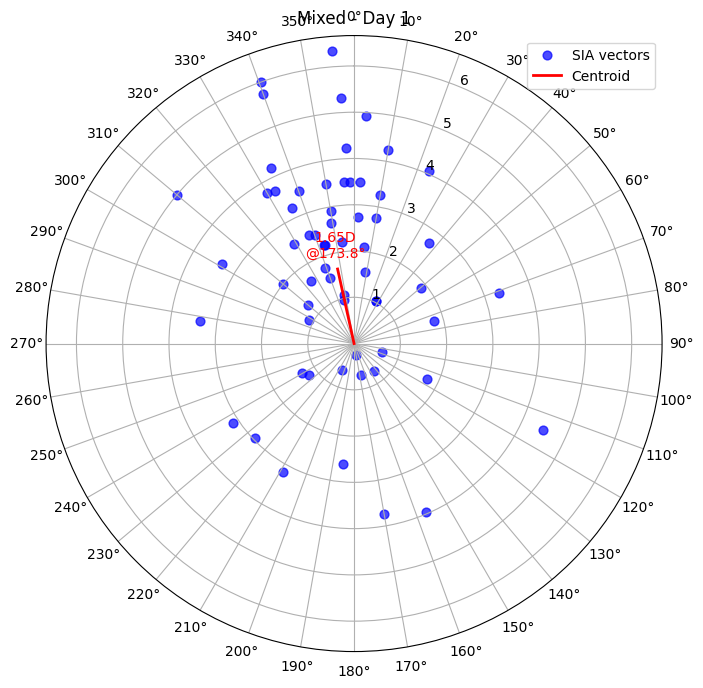

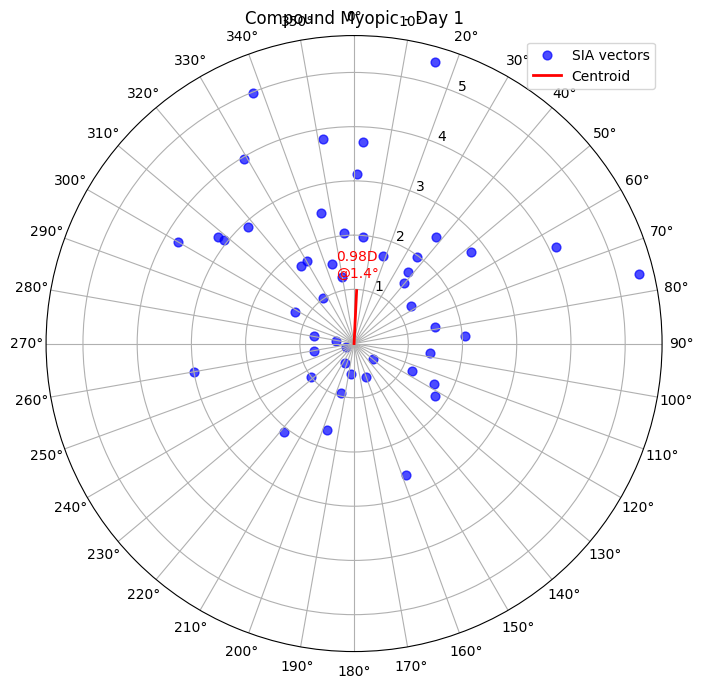

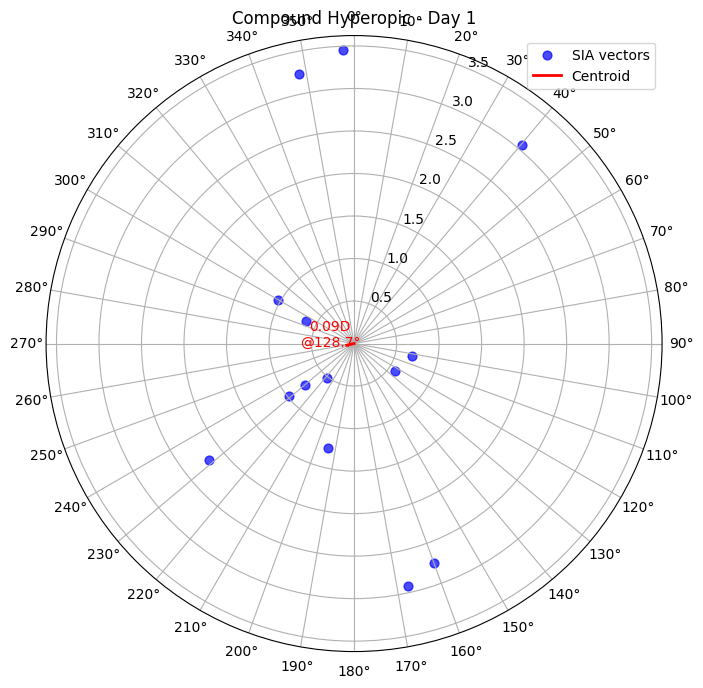

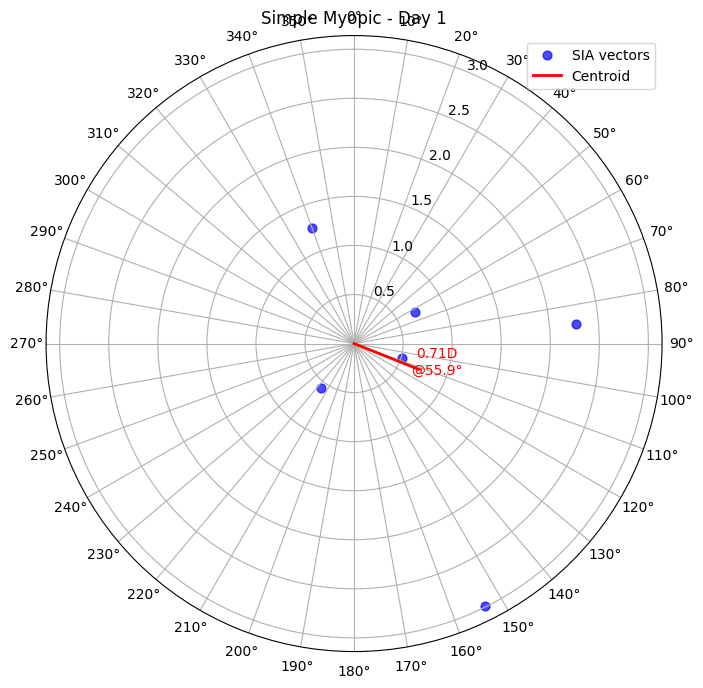

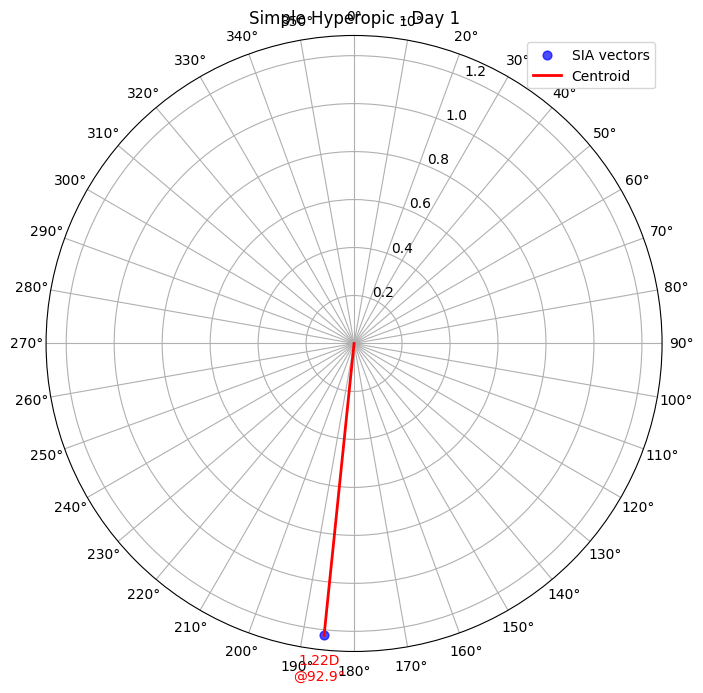

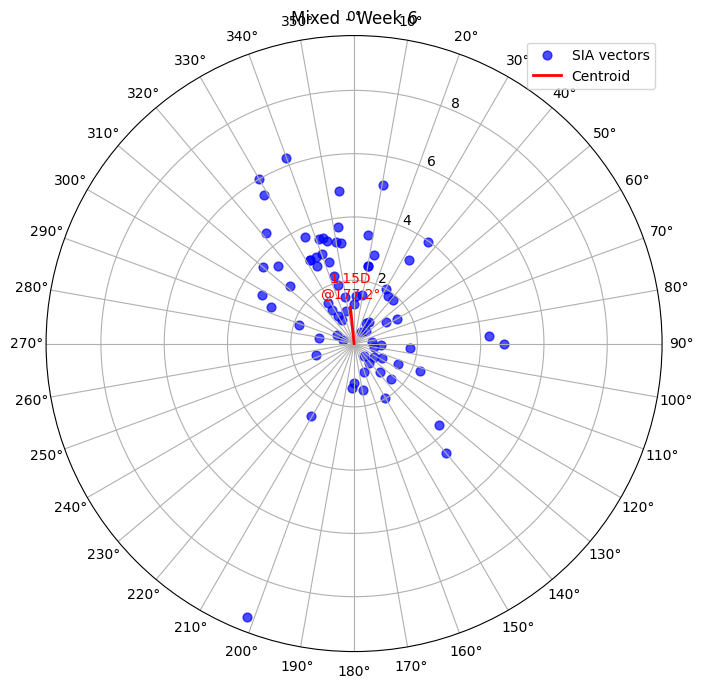

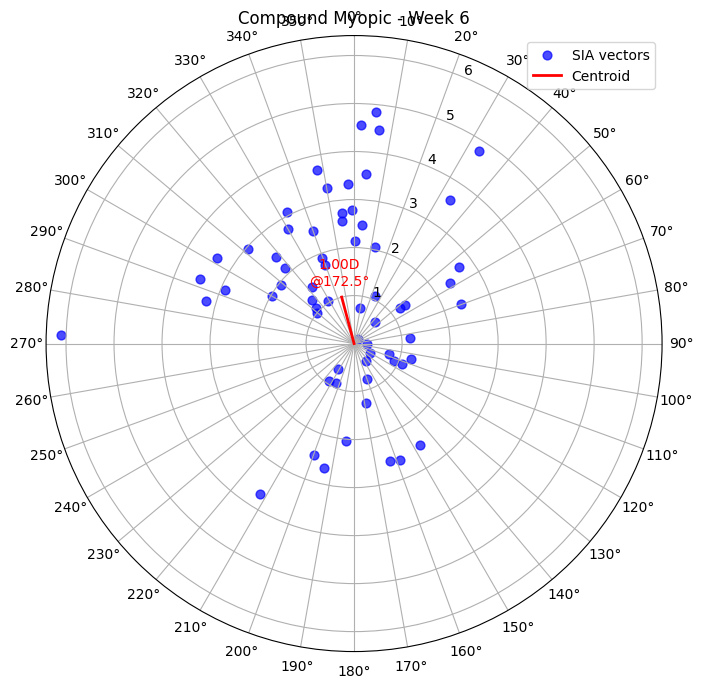

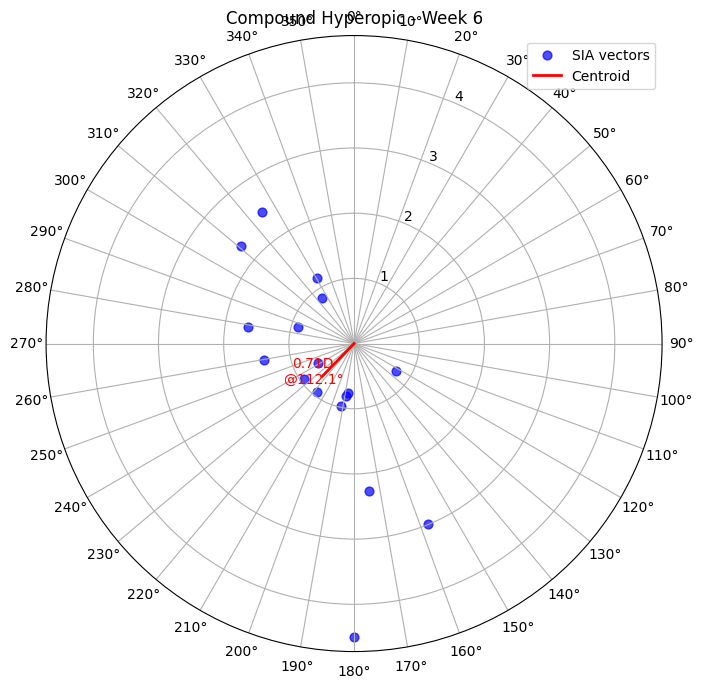

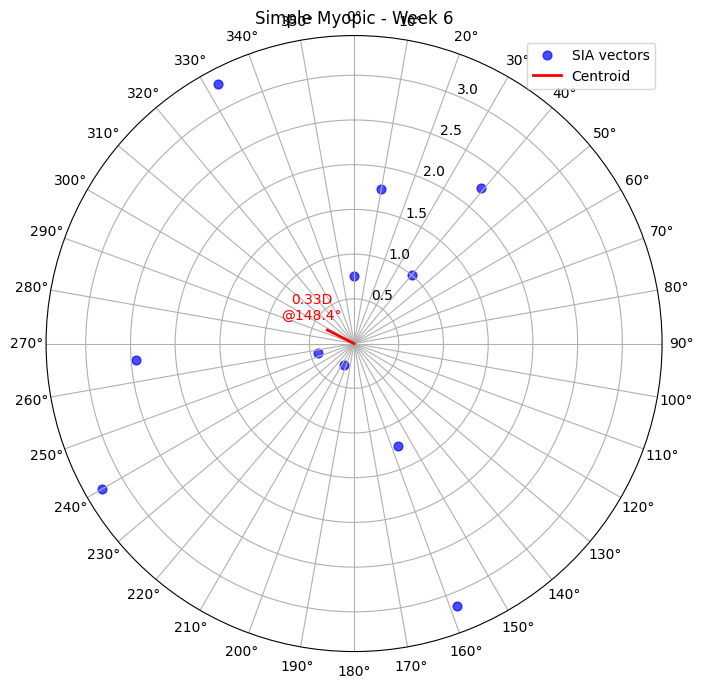

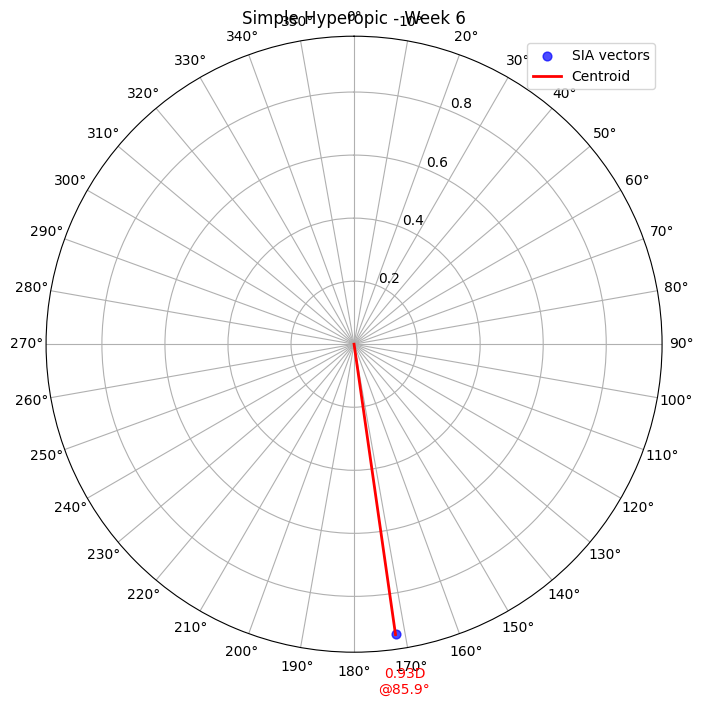

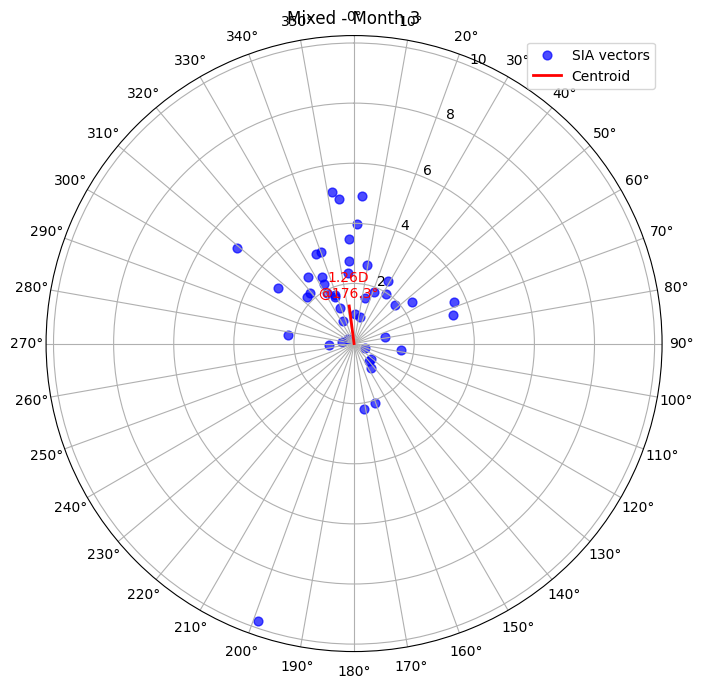

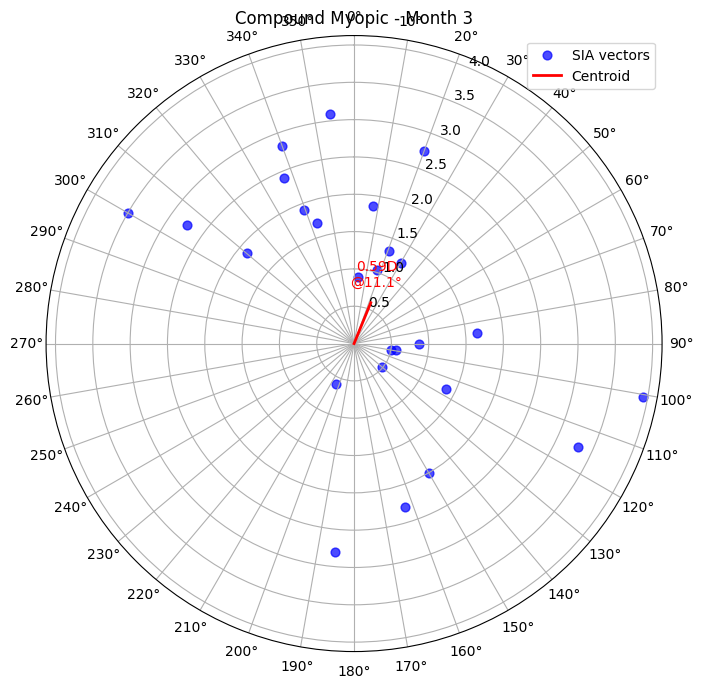

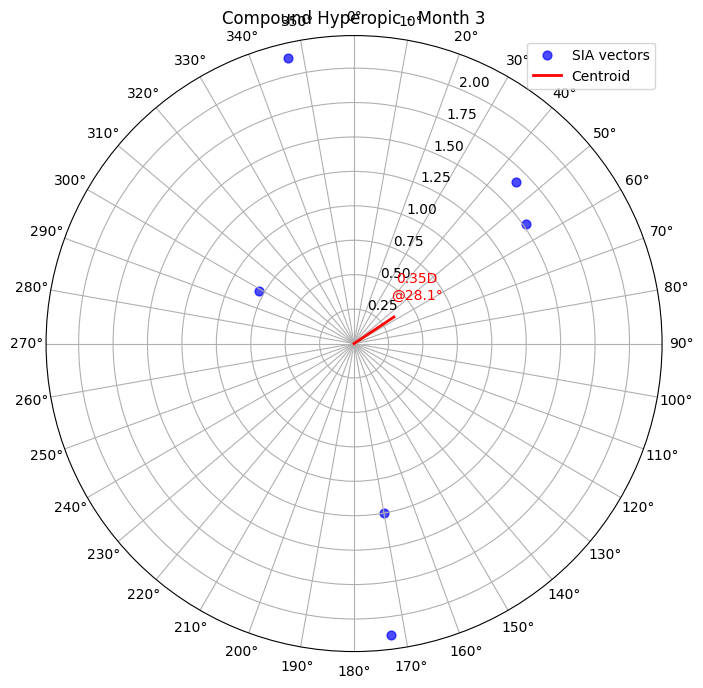

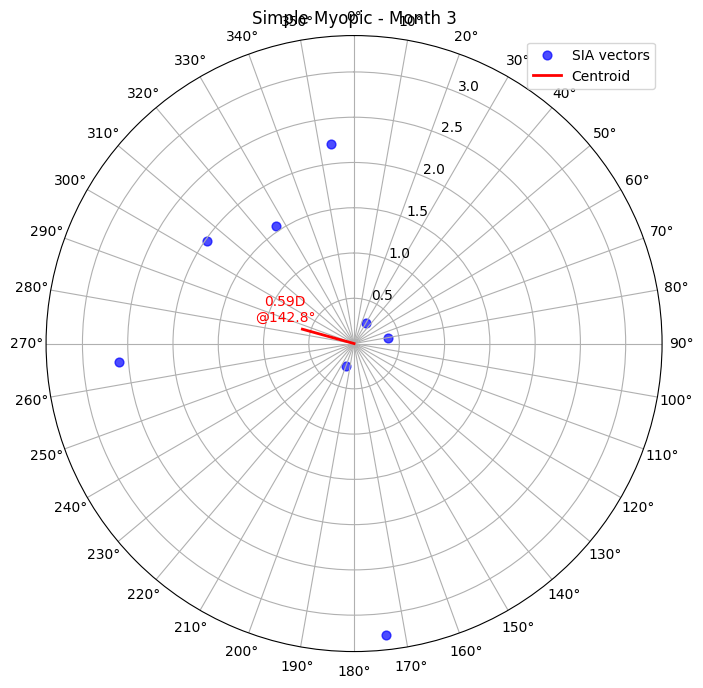

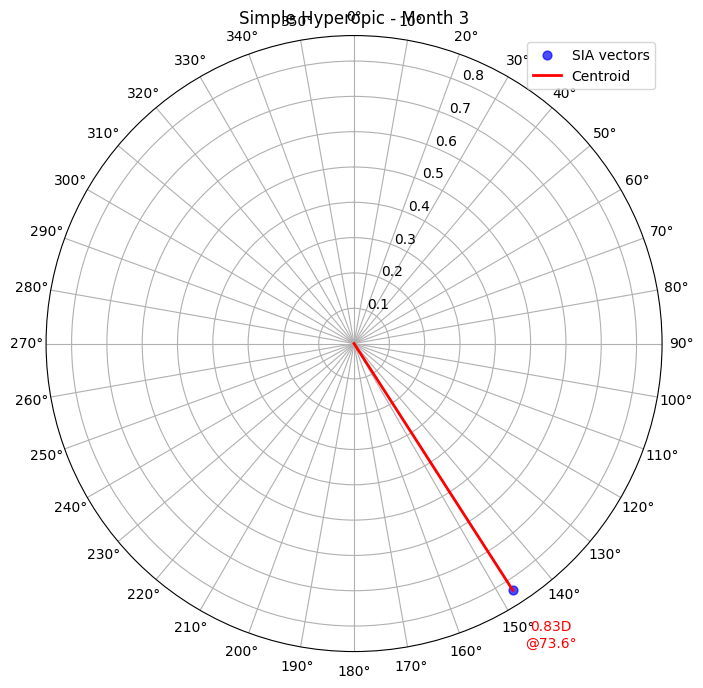

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Function to create polar plot for a given dataframe and title
def plot_sia_polar(df, title):
    # Ensure required columns exist
    required_cols = ['sia_x', 'sia_y', 'SIA_magnitude', 'SIA_axis']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Skipping plot for {title} due to missing columns: {missing_cols}")
        return

    # --- Compute centroid ---
    centroid_x = df['sia_x'].mean()
    centroid_y = df['sia_y'].mean()
    centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
    centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
    centroid_theta = np.deg2rad(centroid_axis * 2)


    # --- Convert data points to polar ---
    theta = np.deg2rad(df['SIA_axis'] * 2)  # double-angle domain
    r = df['SIA_magnitude']

    # --- Plot ---
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.arange(0, 360, 10))  # 10° spacing

    # Plot SIA data points
    ax.scatter(theta, r, color='blue', s=40, alpha=0.7, label='SIA vectors')

    # Plot centroid vector
    ax.plot([0, centroid_theta], [0, centroid_mag], color='red', linewidth=2, label='Centroid')

    # Label the centroid
    # Adjust text position if necessary to avoid overlap
    text_offset = 0.2
    ax.text(centroid_theta, centroid_mag + text_offset,
            f"{centroid_mag:.2f}D\n@{centroid_axis:.1f}°",
            ha='center', va='bottom', fontsize=10, color='red')

    # Final formatting
    ax.set_title(title, va='bottom')
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.show()

# Get unique groups and timepoints
groups = all_sia_data['Group'].unique()
timepoints = all_sia_data['Timepoint'].unique()

# Generate polar plots for each group at each timepoint
for timepoint in timepoints:
    for group in groups:
        df_subset = all_sia_data[(all_sia_data['Timepoint'] == timepoint) & (all_sia_data['Group'] == group)].copy()
        # Only plot if there is data for the group at this timepoint
        if not df_subset.empty:
            plot_title = f"{group} - {timepoint}"
            plot_sia_polar(df_subset, plot_title)

### Summary of SIA Analysis Results

Based on the statistical tests and polar plots, here is a summary of the SIA analysis for each astigmatism group across the different time points:

**Statistical Tests for SIA Magnitude:**

*   **Day 1:** The Kruskal-Wallis test showed a statistically significant difference in SIA magnitude between the astigmatism groups (p = 0.0057). This suggests that the amount of surgically induced astigmatism on Day 1 is significantly different depending on the type of astigmatism the patient had pre-operatively.
*   **Week 6:** The Kruskal-Wallis test did not show a statistically significant difference in SIA magnitude between the groups (p = 0.0891).
*   **Month 3:** The Kruskal-Wallis test did not show a statistically significant difference in SIA magnitude between the groups (p = 0.2782).

**Interpretation of SIA Magnitude Results:**

The significant difference in SIA magnitude on Day 1 indicates that the immediate post-operative astigmatic change varies among the different astigmatism types. However, by Week 6 and Month 3, these differences in the *amount* of induced astigmatism become less pronounced and are no longer statistically significant. This might suggest that while the initial response to surgery differs, the magnitude of the remaining induced astigmatism tends to equalize over time across the groups.

**Interpretation of SIA Axis (from Polar Plots):**

Observing the polar plots for each group and time point:

*   **Mixed Astigmatism:** The SIA vectors appear more scattered across different axes at all time points, although there might be some clustering in certain areas. The centroid vector can help identify the average direction and magnitude of SIA for this diverse group.
*   **Compound Myopic Astigmatism:** The SIA vectors show some clustering, particularly around certain axes. Changes in the clustering or the centroid vector over time might indicate a shift in the predominant direction of surgically induced astigmatism in this group.
*   **Compound Hyperopic Astigmatism:** With fewer data points, it is harder to draw definitive conclusions from the scatter. The centroid vector provides the average SIA for this group.
*   **Simple Myopic Astigmatism:** The small sample size makes it difficult to discern clear patterns or significant changes over time from the polar plots alone. The centroid vector represents the average SIA.
*   **Simple Hyperopic Astigmatism:** With only one data point at each time point, the polar plot simply shows the individual SIA vector and its magnitude and axis. No meaningful statistical comparisons or pattern observations can be made for this group.

**Overall Interpretation:**

The analysis of SIA magnitude suggests that the initial surgically induced astigmatism differs based on pre-operative astigmatism type, but this difference diminishes over the follow-up period. The polar plots provide a visual representation of the distribution of SIA axes, which appears to vary across the astigmatism groups. While formal statistical comparison of axes was not feasible with standard libraries and the given data distribution, the plots offer valuable insights into the directional patterns of induced astigmatism within each group.

In [97]:
import pandas as pd

# --- Helper functions ---
def sia_summary(df, label):
    return {
        "Group": label,
        "n": len(df),
        "SIA_magnitude (Mean ± SD)": f"{df['SIA_magnitude'].mean():.2f} ± {df['SIA_magnitude'].std():.2f}",
        "SIA_axis (Mean ± SD)": f"{df['SIA_axis'].mean():.1f} ± {df['SIA_axis'].std():.1f}"
    }

def logmar_summary(df, pre, d1, wk6, m3):
    return {
        "logMAR Pre-op (Mean ± SD)": f"{df[pre].mean():.2f} ± {df[pre].std():.2f}",
        "logMAR Day1 (Mean ± SD)": f"{df[d1].mean():.2f} ± {df[d1].std():.2f}",
        "logMAR Week6 (Mean ± SD)": f"{df[wk6].mean():.2f} ± {df[wk6].std():.2f}",
        "logMAR Month3 (Mean ± SD)": f"{df[m3].mean():.2f} ± {df[m3].std():.2f}"
    }

# --- Build master summary ---
summary_list = []

# C_myopic
sia_part = sia_summary(C_myopic_df1, "C_myopic")
logmar_part = logmar_summary(C_myopic_df1, "preop logMAR", "day1 logMAR", "wk6 logMAR", "mth3 logMAR")
summary_list.append({**sia_part, **logmar_part})

# C_hyperopic
sia_part = sia_summary(C_hyperopic_df1, "C_hyperopic")
logmar_part = logmar_summary(C_hyperopic_df1, "preop logMAR", "day1 logMAR", "wk6 logMAR", "mth3 logMAR")
summary_list.append({**sia_part, **logmar_part})

# S_myopic
sia_part = sia_summary(S_myopic_df1, "S_myopic")
logmar_part = logmar_summary(S_myopic_df1, "preop logMAR", "day1 logMAR", "wk6 logMAR", "mth3 logMAR")
summary_list.append({**sia_part, **logmar_part})

# S_hyperopic
sia_part = sia_summary(S_hyperopic_df1, "S_hyperopic")
logmar_part = logmar_summary(S_hyperopic_df1, "preop logMAR", "day1 logMAR", "wk6 logMAR", "mth3 logMAR")
summary_list.append({**sia_part, **logmar_part})

# Mixed
sia_part = sia_summary(mixed_df1, "Mixed")
logmar_part = logmar_summary(mixed_df1, "preop logMAR", "day1 logMAR", "wk6 logMAR", "mth3 logMAR")
summary_list.append({**sia_part, **logmar_part})

# --- Convert to DataFrame ---
master_summary = pd.DataFrame(summary_list)

# Show table
print(master_summary)


KeyError: 'wk6 logMAR'

In [96]:
wk6AR.columns

Index(['AGE', 'SEX_numeric', 'KH', 'KV', 'AX', 'POD 6 WEEK V/A ', 'numerator',
       'denominator', 'wk6 logMAR', 'SPH ', 'CYL.1', 'AXIS.1'],
      dtype='object')

In [98]:
import pandas as pd

# --- Helper functions ---
def sia_summary(df, label):
    return {
        "Group": label,
        "n": len(df),
        "SIA_magnitude (Mean ± SD)": f"{df['SIA_magnitude'].mean():.2f} ± {df['SIA_magnitude'].std():.2f}",
        "SIA_axis (Mean ± SD)": f"{df['SIA_axis'].mean():.1f} ± {df['SIA_axis'].std():.1f}"
    }

# Helper function to summarize logMAR for a given group dataframe
def logmar_summary_group(df_group, group_label):
    summary = {"Group": group_label, "n": len(df_group)}
    logmar_cols = {
        "Pre-op": "preop logMAR",
        "Day 1": "day1 logMAR",
        "Week 6": "wk6 logMAR",
        "Month 3": "mth3 logMAR"
    }
    for label, col in logmar_cols.items():
        if col in df_group.columns and df_group[col].notna().any():
            summary[f"logMAR {label} (Mean ± SD)"] = f"{df_group[col].mean():.2f} ± {df_group[col].std():.2f}"
        else:
            summary[f"logMAR {label} (Mean ± SD)"] = "N/A" # Handle cases where the column is missing or all values are NaN

    return summary


# --- Build master summary ---
summary_list = []

# Collect summaries for each group across timepoints
summary_list.append(logmar_summary_group(C_myopic_df1, "C_myopic"))
summary_list.append(logmar_summary_group(C_hyperopic_df1, "C_hyperopic"))
summary_list.append(logmar_summary_group(S_myopic_df1, "S_myopic"))
summary_list.append(logmar_summary_group(S_hyperopic_df1, "S_hyperopic"))
summary_list.append(logmar_summary_group(mixed_df1, "Mixed"))

# Combine SIA summaries for each group (assuming you want the overall SIA summary per group)
summary_list.append(sia_summary(C_myopic_df1, "C_myopic"))
summary_list.append(sia_summary(C_hyperopic_df1, "C_hyperopic"))
summary_list.append(sia_summary(S_myopic_df1, "S_myopic"))
summary_list.append(sia_summary(S_hyperopic_df1, "S_hyperopic"))
summary_list.append(sia_summary(mixed_df1, "Mixed"))


# Convert to DataFrame
master_summary = pd.DataFrame(summary_list)

# Show table
print(master_summary)

         Group   n logMAR Pre-op (Mean ± SD) logMAR Day 1 (Mean ± SD)  \
0     C_myopic  48               1.39 ± 0.73              0.39 ± 0.24   
1  C_hyperopic  14               1.33 ± 0.61              0.43 ± 0.20   
2     S_myopic   6               1.39 ± 0.67              0.22 ± 0.16   
3  S_hyperopic   1                0.60 ± nan               0.18 ± nan   
4        Mixed  62               1.31 ± 0.60              0.36 ± 0.17   
5     C_myopic  48                       NaN                      NaN   
6  C_hyperopic  14                       NaN                      NaN   
7     S_myopic   6                       NaN                      NaN   
8  S_hyperopic   1                       NaN                      NaN   
9        Mixed  62                       NaN                      NaN   

  logMAR Week 6 (Mean ± SD) logMAR Month 3 (Mean ± SD)  \
0                       N/A                        N/A   
1                       N/A                        N/A   
2                     